## Setup for EDA and time series 

In [379]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [380]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report

from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing


from statsmodels.tsa.statespace.sarimax import SARIMAX
#New Libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
import matplotlib.dates as mdates  


In [381]:
#from statsmodels.tsa.stattools import adfuller
#!pip install pmdarima --quiet
#import pmdarima as pm


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 
- df_dt is final dataframe for XG Boost regressor (only contain the 'datatime' and  'target' features)

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

#### Daily data import (for 10 states in Germany)

In [382]:
#df_daily.csv,  weather_daily_10loc.csv, df_m_all.csv
df_daily = pd.read_csv('data/df_daily.csv')
df_weather_daily_10loc = pd.read_csv('data/weather_daily_10loc.csv')
df_daily.head()

,dt_date_hour,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,geothermal_mwh,...,dt_month,dt_week,dt_dayofweek,dt_dayofmonth,dt_dayofyear,dt_monthname,dt_dayname,dt_date,solar_gwh,total_energy_generation_gwh
0,2015-01-01 00:00:00+01:00,95550.50,314599.00,0.0,23806.00,60725.25,4265.75,0.0,0.0,234.00,...,1,1,3,1,1,January,Thursday,2015-01-01,17.08025,1271.68350
1,2015-01-02 00:00:00+01:00,94404.00,257344.00,0.0,29919.25,83617.25,4408.75,0.0,0.0,243.00,...,1,1,4,2,2,January,Friday,2015-01-02,7.75900,1493.59800
2,2015-01-03 00:00:00+01:00,94487.75,296727.50,0.0,29790.75,60999.25,4614.00,0.0,0.0,247.75,...,1,1,5,3,3,January,Saturday,2015-01-03,7.23475,1408.94650
3,2015-01-04 00:00:00+01:00,94764.75,287900.50,0.0,21470.75,47224.50,4627.25,0.0,0.0,263.00,...,1,1,6,4,4,January,Sunday,2015-01-04,19.98250,1325.84900
4,2015-01-05 00:00:00+01:00,94243.25,405171.25,0.0,35151.75,177046.75,4511.00,0.0,0.0,269.00,...,1,2,0,5,5,January,Monday,2015-01-05,26.52225,1521.12275


In [383]:
##  Capitalize the columns names
df_daily.columns = [col.capitalize() for col in df_daily.columns]
df_daily.rename(columns = {'Dt_date': 'Date'}, inplace = True)  
df_daily.head()

# Print the dataframe
df_daily.head()

,Dt_date_hour,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,Geothermal_mwh,...,Dt_month,Dt_week,Dt_dayofweek,Dt_dayofmonth,Dt_dayofyear,Dt_monthname,Dt_dayname,Date,Solar_gwh,Total_energy_generation_gwh
0,2015-01-01 00:00:00+01:00,95550.50,314599.00,0.0,23806.00,60725.25,4265.75,0.0,0.0,234.00,...,1,1,3,1,1,January,Thursday,2015-01-01,17.08025,1271.68350
1,2015-01-02 00:00:00+01:00,94404.00,257344.00,0.0,29919.25,83617.25,4408.75,0.0,0.0,243.00,...,1,1,4,2,2,January,Friday,2015-01-02,7.75900,1493.59800
2,2015-01-03 00:00:00+01:00,94487.75,296727.50,0.0,29790.75,60999.25,4614.00,0.0,0.0,247.75,...,1,1,5,3,3,January,Saturday,2015-01-03,7.23475,1408.94650
3,2015-01-04 00:00:00+01:00,94764.75,287900.50,0.0,21470.75,47224.50,4627.25,0.0,0.0,263.00,...,1,1,6,4,4,January,Sunday,2015-01-04,19.98250,1325.84900
4,2015-01-05 00:00:00+01:00,94243.25,405171.25,0.0,35151.75,177046.75,4511.00,0.0,0.0,269.00,...,1,2,0,5,5,January,Monday,2015-01-05,26.52225,1521.12275


In [384]:
df_daily['Date'] = pd.to_datetime(df_daily['Date'], format='%Y-%m-%d')
# Extract year, month and date from the datetime object
df_daily['Year'] = df_daily['Date'].dt.year
df_daily['Month'] = df_daily['Date'].dt.month
df_daily['Day'] = df_daily['Date'].dt.day
#df_daily['Dayofyear'] = df_dailyf['Dt_date_hour'].dt.dayofyear
df_daily.head()

,Dt_date_hour,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,Geothermal_mwh,...,Dt_dayofmonth,Dt_dayofyear,Dt_monthname,Dt_dayname,Date,Solar_gwh,Total_energy_generation_gwh,Year,Month,Day
0,2015-01-01 00:00:00+01:00,95550.50,314599.00,0.0,23806.00,60725.25,4265.75,0.0,0.0,234.00,...,1,1,January,Thursday,2015-01-01,17.08025,1271.68350,2015,1,1
1,2015-01-02 00:00:00+01:00,94404.00,257344.00,0.0,29919.25,83617.25,4408.75,0.0,0.0,243.00,...,2,2,January,Friday,2015-01-02,7.75900,1493.59800,2015,1,2
2,2015-01-03 00:00:00+01:00,94487.75,296727.50,0.0,29790.75,60999.25,4614.00,0.0,0.0,247.75,...,3,3,January,Saturday,2015-01-03,7.23475,1408.94650,2015,1,3
3,2015-01-04 00:00:00+01:00,94764.75,287900.50,0.0,21470.75,47224.50,4627.25,0.0,0.0,263.00,...,4,4,January,Sunday,2015-01-04,19.98250,1325.84900,2015,1,4
4,2015-01-05 00:00:00+01:00,94243.25,405171.25,0.0,35151.75,177046.75,4511.00,0.0,0.0,269.00,...,5,5,January,Monday,2015-01-05,26.52225,1521.12275,2015,1,5


In [385]:
df_daily.columns

Index(['Dt_date_hour', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Total_energy_generation_mwh', 'Dt_year', 'Dt_month', 'Dt_week',
       'Dt_dayofweek', 'Dt_dayofmonth', 'Dt_dayofyear', 'Dt_monthname',
       'Dt_dayname', 'Date', 'Solar_gwh', 'Total_energy_generation_gwh',
       'Year', 'Month', 'Day'],
      dtype='object')

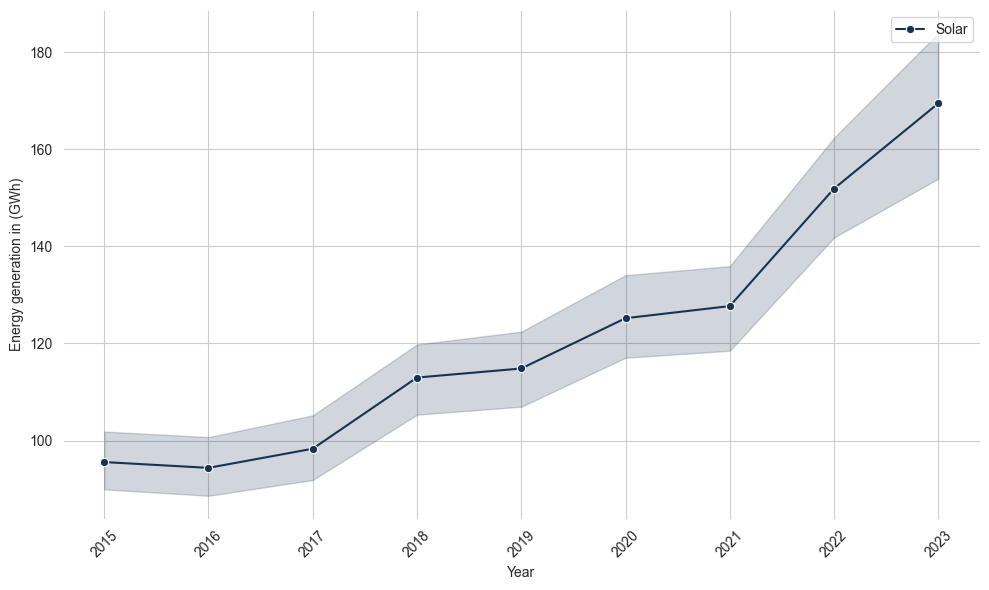

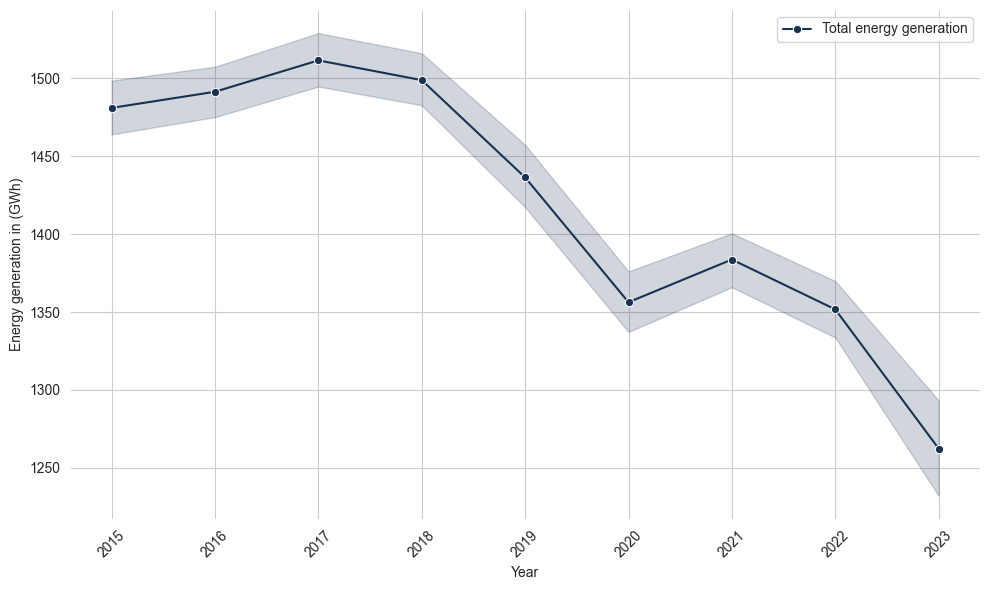

In [386]:
def average_lineplot(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

def simple_lineplot(df, y_values, x='Date', time=' '):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Weather conditions')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

average_lineplot(df=df_daily, y_values=['Solar_gwh'], x="Date", time='Year')   
average_lineplot(df=df_daily, y_values=['Total_energy_generation_gwh'], x="Date", time='Year')  
#average_lineplot(df=data_df, y_values=['Total_energy_generation_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
#average_lineplot(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')

#### Univariate  time series analysis

In [387]:
Columns_Uni = ['Date', 'Year', 'Month', 'Day', 'Solar_gwh']
df_daily_Uni = df_daily[Columns_Uni].copy()
df_daily_Uni.head()

,Date,Year,Month,Day,Solar_gwh
0,2015-01-01,2015,1,1,17.08025
1,2015-01-02,2015,1,2,7.75900
2,2015-01-03,2015,1,3,7.23475
3,2015-01-04,2015,1,4,19.98250
4,2015-01-05,2015,1,5,26.52225


In [388]:
df_daily_Uni.columns, df_daily_Uni.index, df_daily_Uni.values

(Index(['Date', 'Year', 'Month', 'Day', 'Solar_gwh'], dtype='object'),
 RangeIndex(start=0, stop=3119, step=1),
 array([[Timestamp('2015-01-01 00:00:00'), 2015, 1, 1, 17.08025],
        [Timestamp('2015-01-02 00:00:00'), 2015, 1, 2, 7.759],
        [Timestamp('2015-01-03 00:00:00'), 2015, 1, 3, 7.23475],
        ...,
        [Timestamp('2023-07-14 00:00:00'), 2023, 7, 14, 290.87575],
        [Timestamp('2023-07-15 00:00:00'), 2023, 7, 15, 267.57125],
        [Timestamp('2023-07-16 00:00:00'), 2023, 7, 16, 271.855]],
       dtype=object))

<Axes: xlabel='Date'>

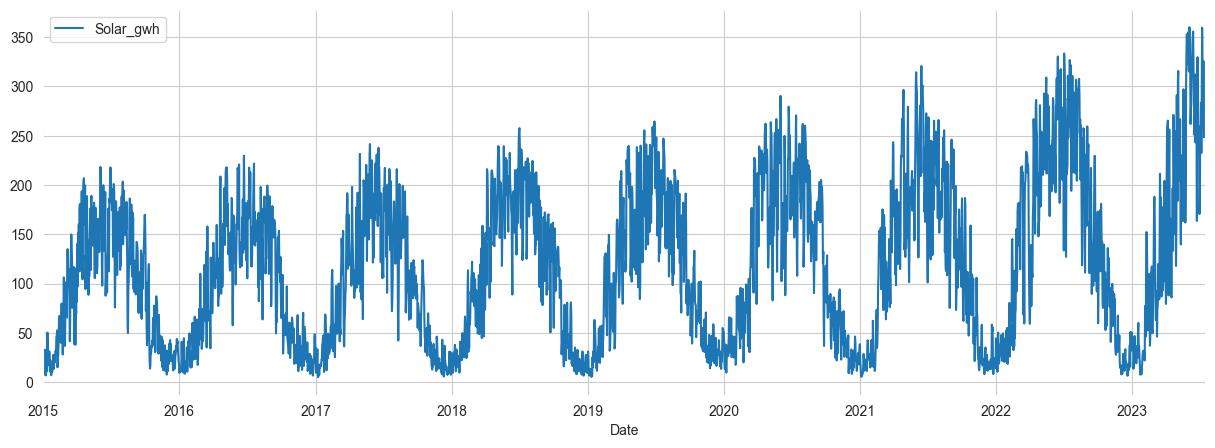

In [390]:
#f_c = df_daily_Uni.copy()
clm = ['Date',  target]
df_c = df_daily_Uni[clm].copy()
df_dt = df_c.set_index('Date')
df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

In [391]:
df_dt.head()

,Solar_gwh
Date,
2015-01-01,17.08025
2015-01-02,7.75900
2015-01-03,7.23475
2015-01-04,19.98250
2015-01-05,26.52225


In [346]:
features_Uni =  ['Year', 'Month', 'Day']

 ## XGboost regressors

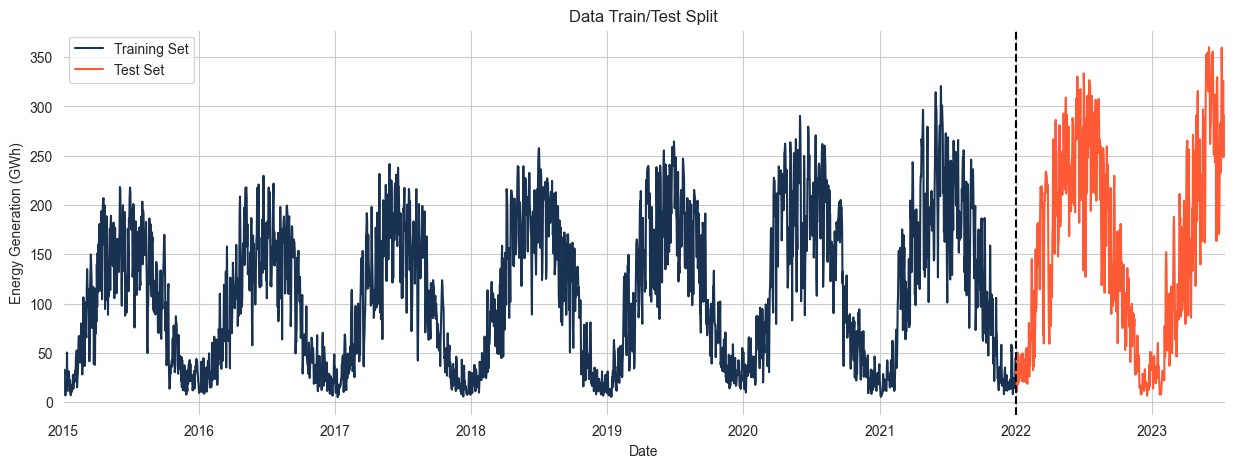

In [393]:
#df_c = pd.DataFrame(df_c.index)
#df_c.index
train =  df_dt.loc[df_dt.index < '2022-01-1']
test =  df_dt.loc[df_dt.index >= '2022-01-1']
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label = 'Training Set', title= 'Data Train/Test Split')
test.plot (ax=ax, ylabel=ylable_target, label = 'Test Set')
ax.axvline('2022-01-1', color = 'black', ls= '--')
ax.legend(['Training Set','Test Set'])
#ax.ylabel(target)
plt.show()

In [394]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    #df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
   # df['Week'] = df.index.week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df

In [395]:
df_dt = create_features(df_dt)
df_dt.head()

,Solar_gwh,Year,Month,Day
Date,,,,
2015-01-01,17.08025,2015,1,1
2015-01-02,7.75900,2015,1,2
2015-01-03,7.23475,2015,1,3
2015-01-04,19.98250,2015,1,4
2015-01-05,26.52225,2015,1,5


In [396]:

train = create_features(train)
test = create_features(test)

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_22025/1148212106.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df.index.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_22025/1148212106.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df.index.month
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_22025/1148212106.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [397]:
features_Uni =  ['Year', 'Month', 'Day']

[0]	validation_0-rmse:95.00029	validation_1-rmse:145.61253
[1]	validation_0-rmse:70.74785	validation_1-rmse:116.22523
[2]	validation_0-rmse:54.71871	validation_1-rmse:96.14885
[3]	validation_0-rmse:44.51827	validation_1-rmse:82.87799
[4]	validation_0-rmse:38.35688	validation_1-rmse:74.30274
[5]	validation_0-rmse:34.83158	validation_1-rmse:68.76897
[6]	validation_0-rmse:32.77191	validation_1-rmse:65.49690
[7]	validation_0-rmse:31.51824	validation_1-rmse:63.19443
[8]	validation_0-rmse:30.85481	validation_1-rmse:61.44059
[9]	validation_0-rmse:30.37060	validation_1-rmse:60.13340
[10]	validation_0-rmse:29.92617	validation_1-rmse:58.39193
[11]	validation_0-rmse:29.67463	validation_1-rmse:57.92152
[12]	validation_0-rmse:29.22441	validation_1-rmse:57.62388
[13]	validation_0-rmse:28.66293	validation_1-rmse:57.08721
[14]	validation_0-rmse:28.28008	validation_1-rmse:57.15966
[15]	validation_0-rmse:28.15220	validation_1-rmse:56.98174
[16]	validation_0-rmse:27.58588	validation_1-rmse:57.01711
[17]	

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[65]	validation_0-rmse:19.35420	validation_1-rmse:60.42725
[66]	validation_0-rmse:19.28312	validation_1-rmse:60.44583
[67]	validation_0-rmse:19.23314	validation_1-rmse:60.46271
[68]	validation_0-rmse:19.10243	validation_1-rmse:60.50476
[69]	validation_0-rmse:19.04237	validation_1-rmse:60.52509
[70]	validation_0-rmse:18.93451	validation_1-rmse:60.57156
[71]	validation_0-rmse:18.89455	validation_1-rmse:60.58827
Mean Squared Error (MSE): 3208.2249935347045
Mean Absolute Error (MAE): 43.98780357950014
Root Mean Squared Error (RMSE): 56.64119519867765
R-squared (R2): 0.6739139977392045


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_22025/3689128216.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = xgb_reg.predict(X_test_scaled)


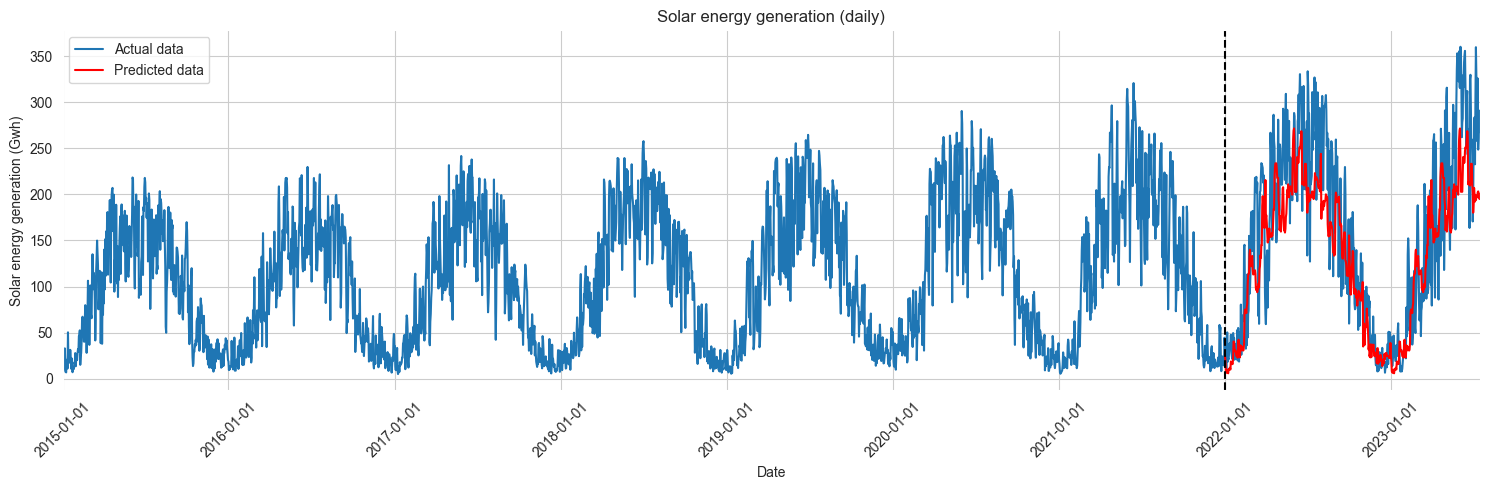

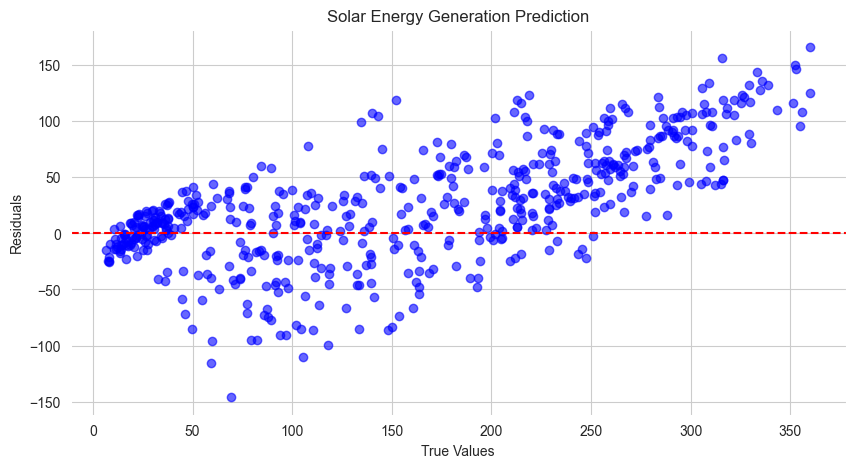

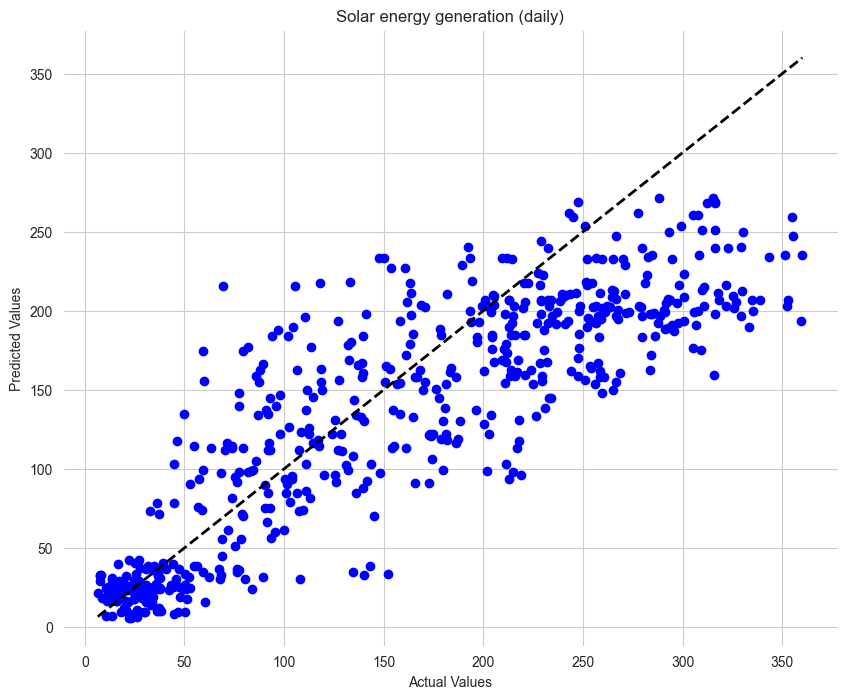

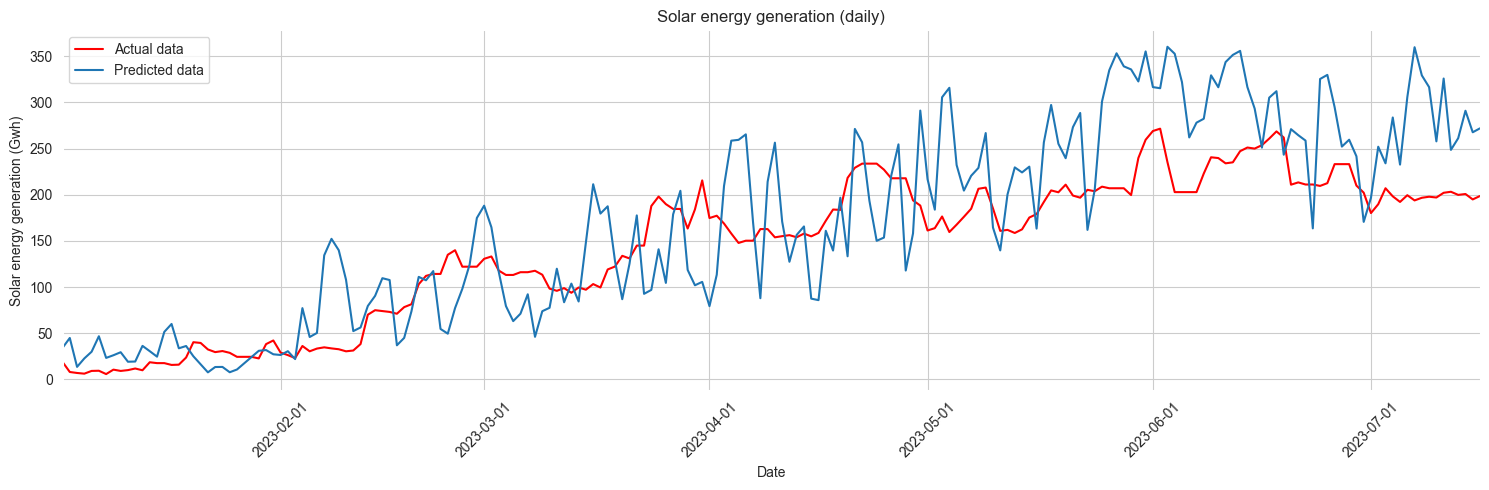

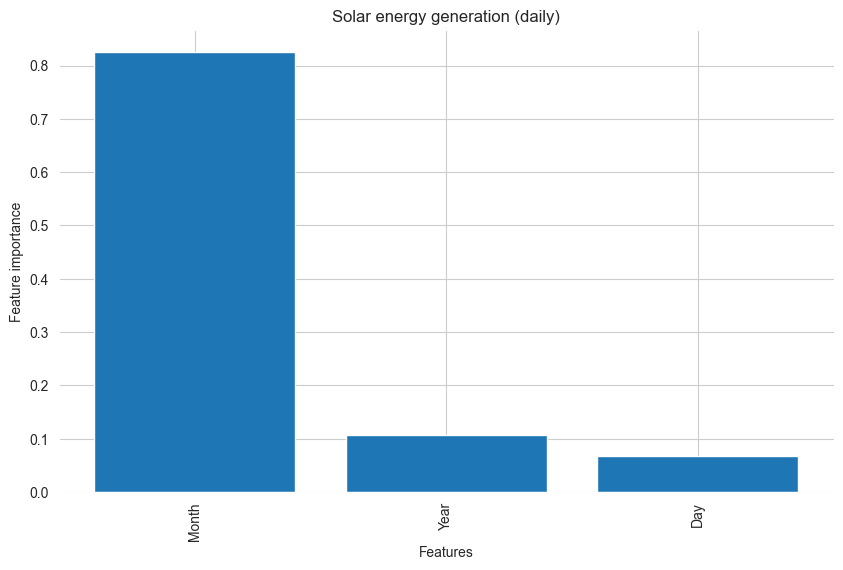

In [406]:
features_Uni =  ['Year', 'Month', 'Day']
X_train = train[features_Uni]
X_test = test[features_Uni]
y_train = train[target]
y_test = test[target]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Scale the features separately for training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
xgb_reg.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)], early_stopping_rounds=50, verbose=True)

# Make predictions on the test set using the fitted model
test['prediction'] = xgb_reg.predict(X_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title=' ')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (Gwh)')#(ylable_target)
ax.set_xlabel('Date')
plt.title('Solar energy generation (daily)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Solar energy generation (daily)')
#plt.title(title_main)
#plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title='')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (Gwh)')#(ylable_target)
plt.title('Solar energy generation (daily)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Get the feature importances
importances = xgb_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Solar energy generation (daily)')
#plt.title(title_main)
plt.show()

#### XGBoost grid search 

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in 

Best parameters found during grid search: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Mean Squared Error (MSE): 3188.9611355594584
Mean Absolute Error (MAE): 44.878957135984486
R-squared (R2): 0.6758719883564233
Root Mean Squared Error (RMSE): 56.4708875046201


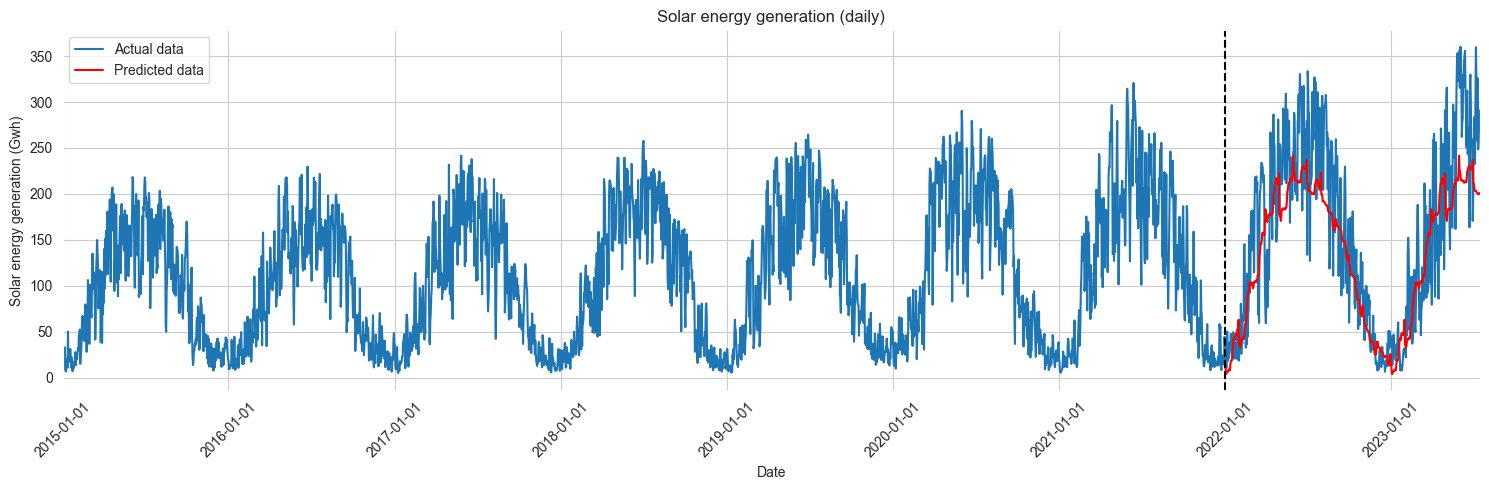

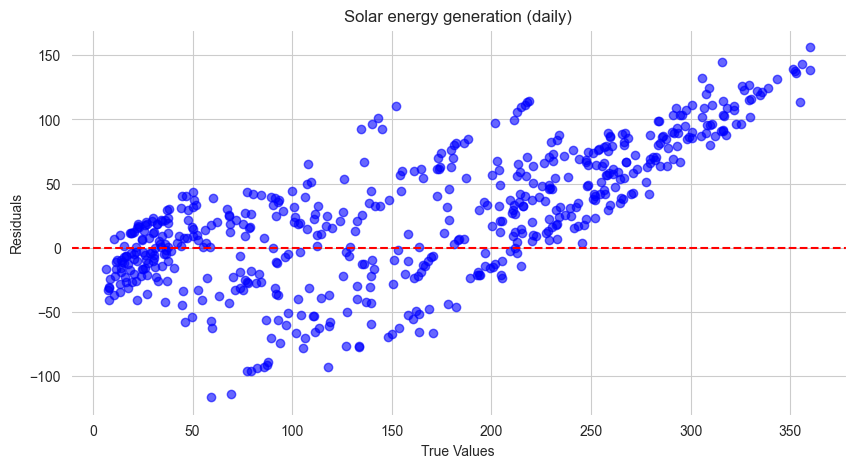

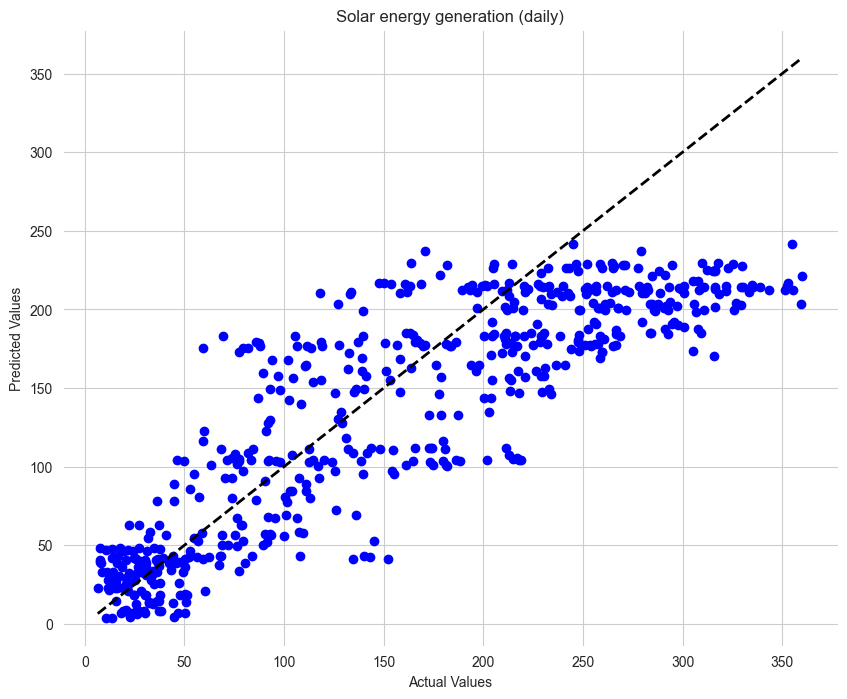

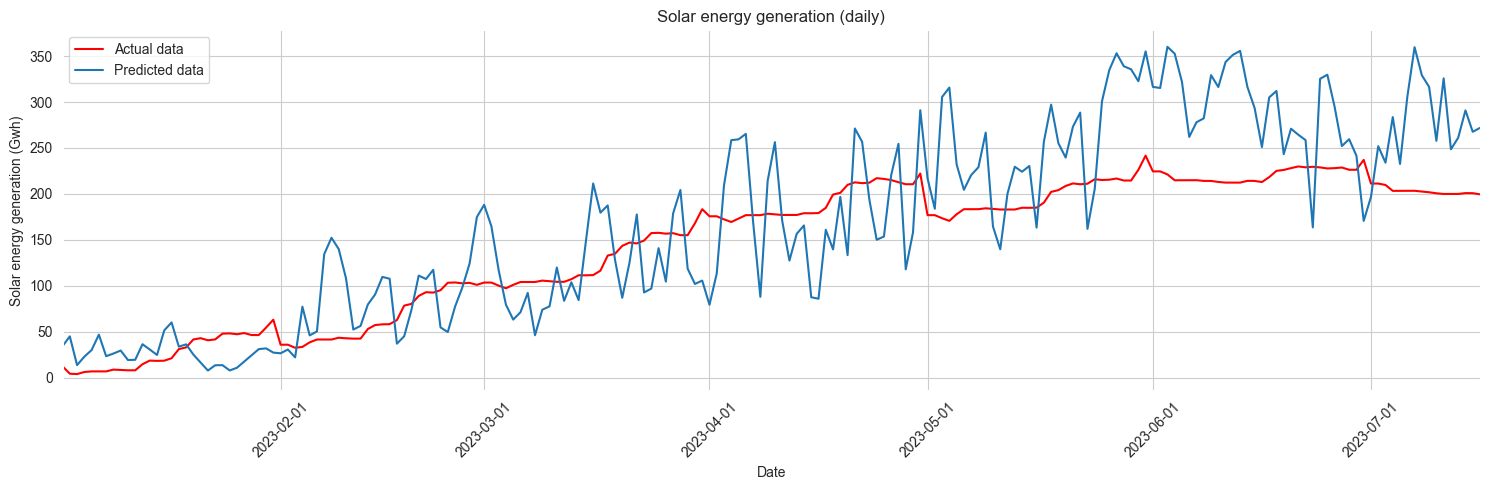

In [407]:
from sklearn.model_selection import GridSearchCV

features_Uni =  ['Year', 'Month', 'Day']

X_train = train[features_Uni]
X_test = test[features_Uni]
y_train = train[target]
y_test = test[target]

# Create an XGBoost regressor
xgb_reg = xgb.XGBRegressor()

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 500, 1000],   # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7],             # Maximum depth of a tree
    'subsample': [0.8, 1.0],            # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0]      # Subsample ratio of columns when constructing each tree
}

# Create GridSearchCV with the XGBoost regressor and parameter grid
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

# Get the best model from the grid search
best_xgb_reg = grid_search.best_estimator_

# Make predictions on the test set using the best model
test['prediction'] = best_xgb_reg.predict(X_test)


# Calculate evaluation metrics for the best model
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
r2 = r2_score(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)


print("Best parameters found during grid search:", grid_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)
print("Root Mean Squared Error (RMSE):", rmse)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title='')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (Gwh)')#(ylable_target)
ax.set_xlabel('Date')
plt.title('Solar energy generation (daily)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
#plt.title(title_main)
plt.title('Solar energy generation (daily)')
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
#plt.title(title_main)
plt.title('Solar energy generation (daily)')
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title='')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (Gwh)')#(ylable_target)
ax.set_xlabel('Date')
plt.title('Solar energy generation (daily)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Univariate random forest  

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_22025/608136388.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = rf_reg.predict(X_test_scaled)


Mean Squared Error (MSE): 3834.850551733713
Mean Absolute Error (MAE): 47.493592829626394
Root Mean Squared Error (RMSE): 61.926170168465234
R-squared (R2): 0.6102233826485132


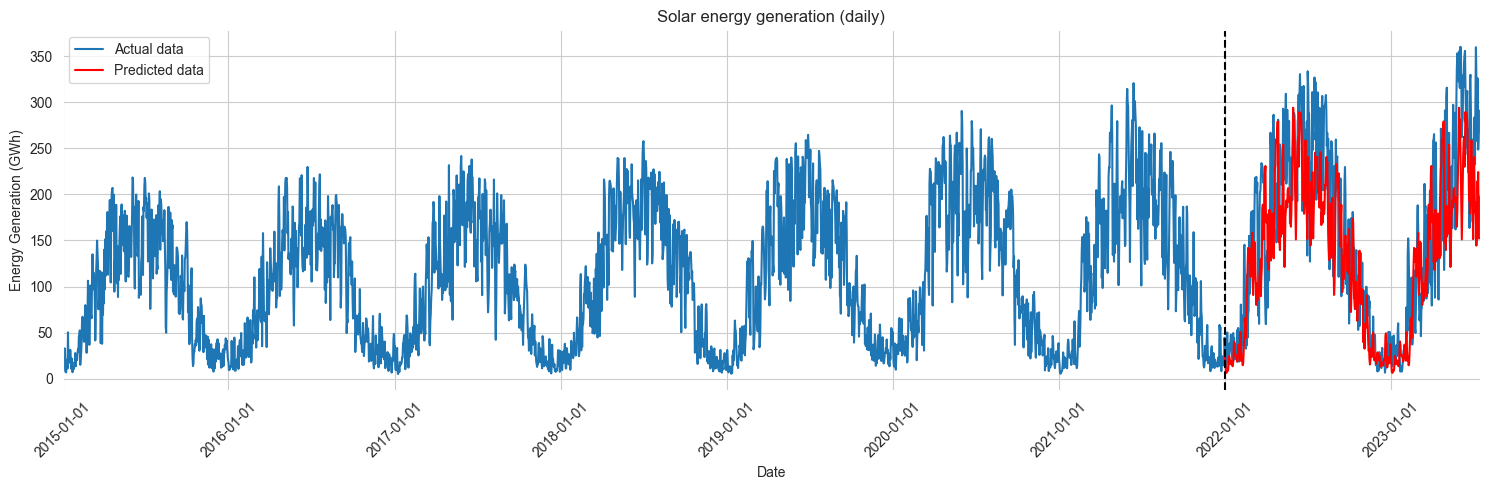

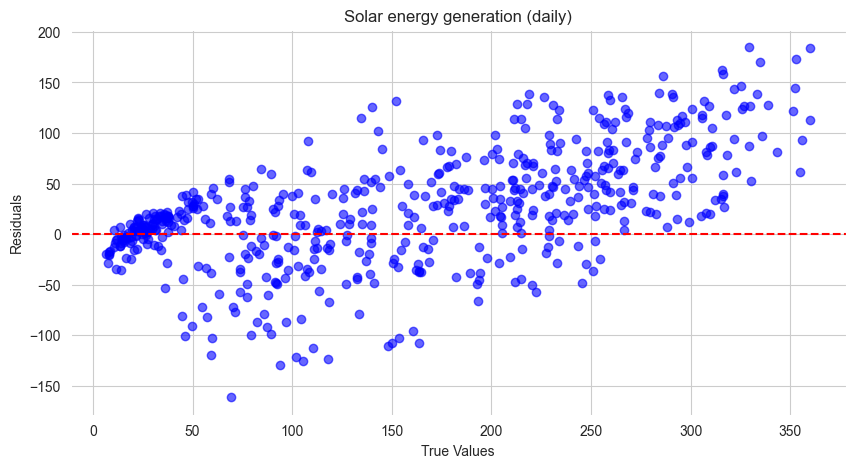

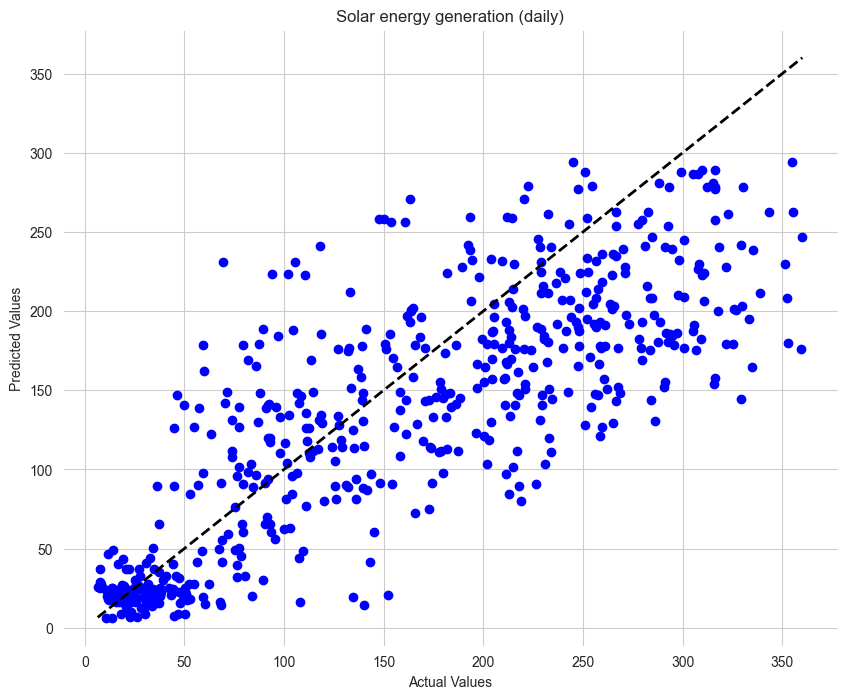

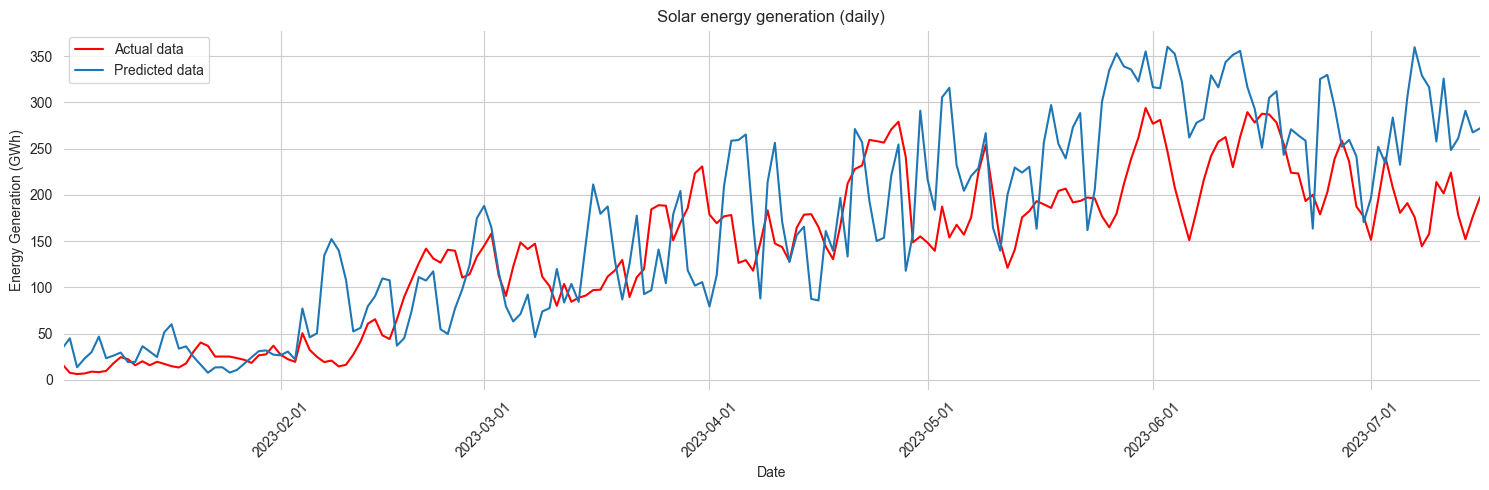

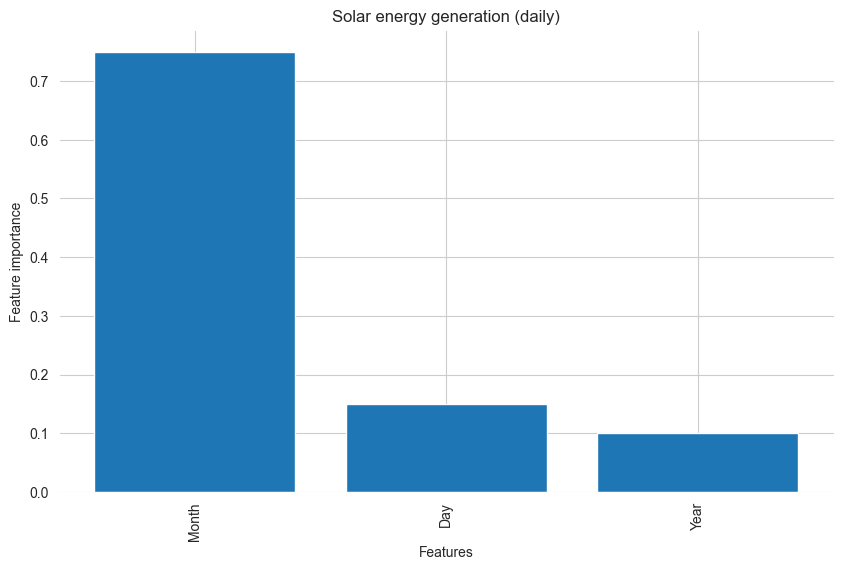

In [403]:
# Extract features and target variables
features_Uni =  ['Year', 'Month', 'Day']

X_train = train[features_Uni]
X_test = test[features_Uni]
y_train = train[target]
y_test = test[target]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=42)

# Fit the model on the scaled training data
rf_reg.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
test['prediction'] = rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title='')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.title('Solar energy generation (daily)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title('Solar energy generation (daily)')#(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Solar energy generation (daily)')
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title='')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel(ylable_target)
ax.set_xlabel('Date')
plt.title('Solar energy generation (daily)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Get the feature importances
importances = rf_reg.feature_importances_
# Create a list of feature names
feature_names = X_train.columns
# Sort feature importances in descending order
indices = importances.argsort()[::-1]
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), importances[indices], align='center', color='#1f76b4')
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Solar energy generation (daily)')
plt.show()


## Grid search for random forest

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_22025/1676075924.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = best_rf_reg.predict(X_test_scaled)


Best parameters found during grid search: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}
Mean Squared Error (MSE): 3765.7041204453485
Mean Absolute Error (MAE): 47.19605634543926
Root Mean Squared Error (RMSE): 61.36533321383783
R-squared (R2): 0.6172514693303582


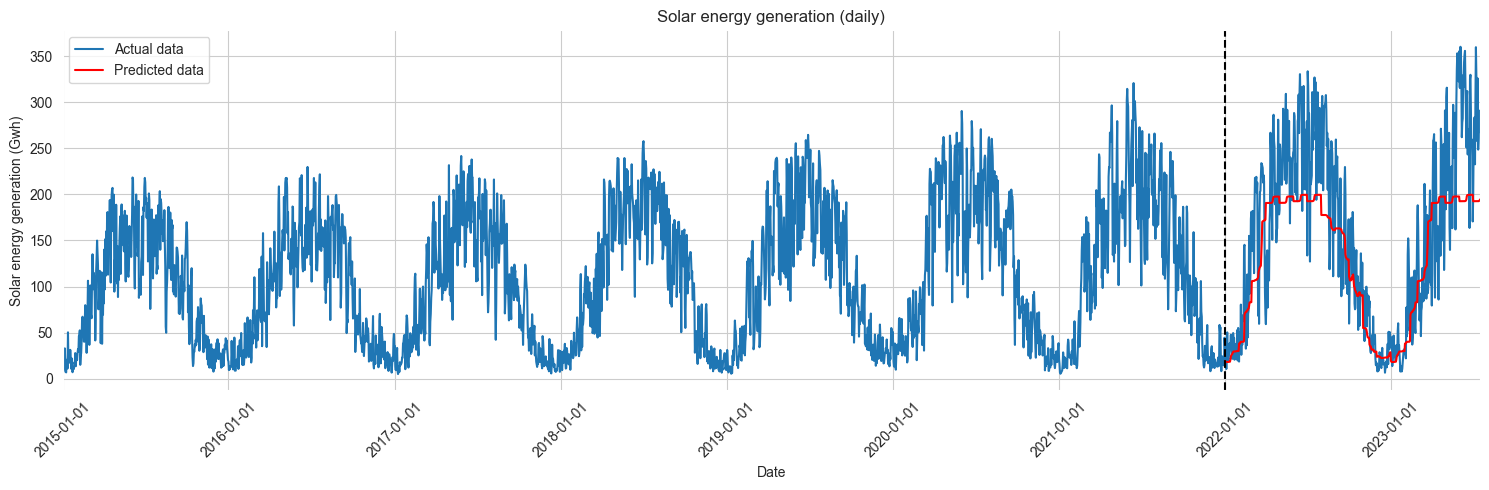

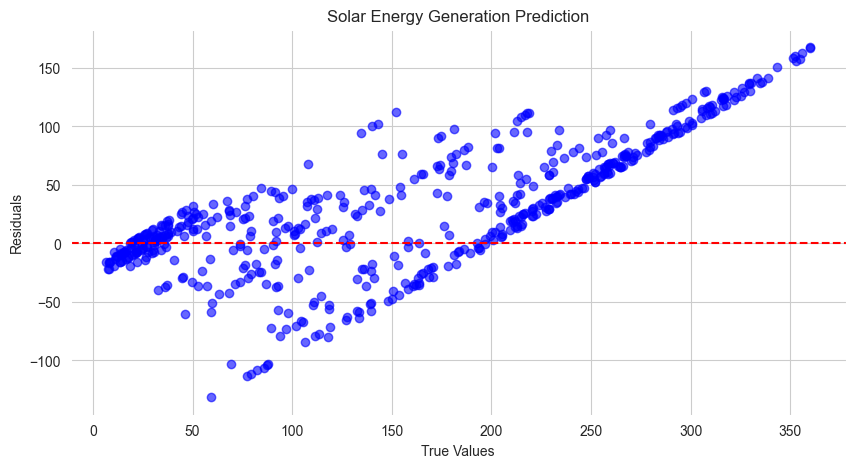

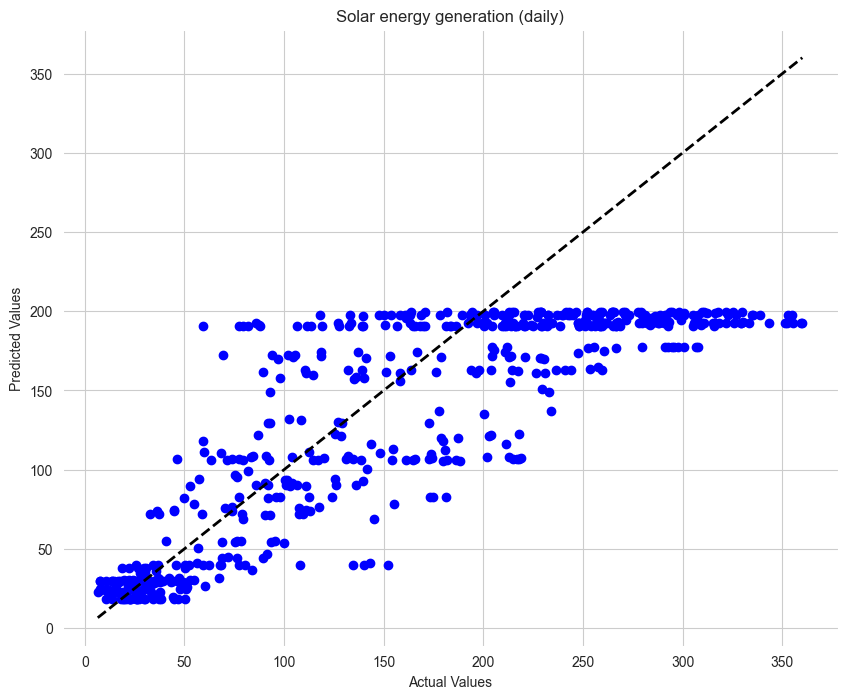

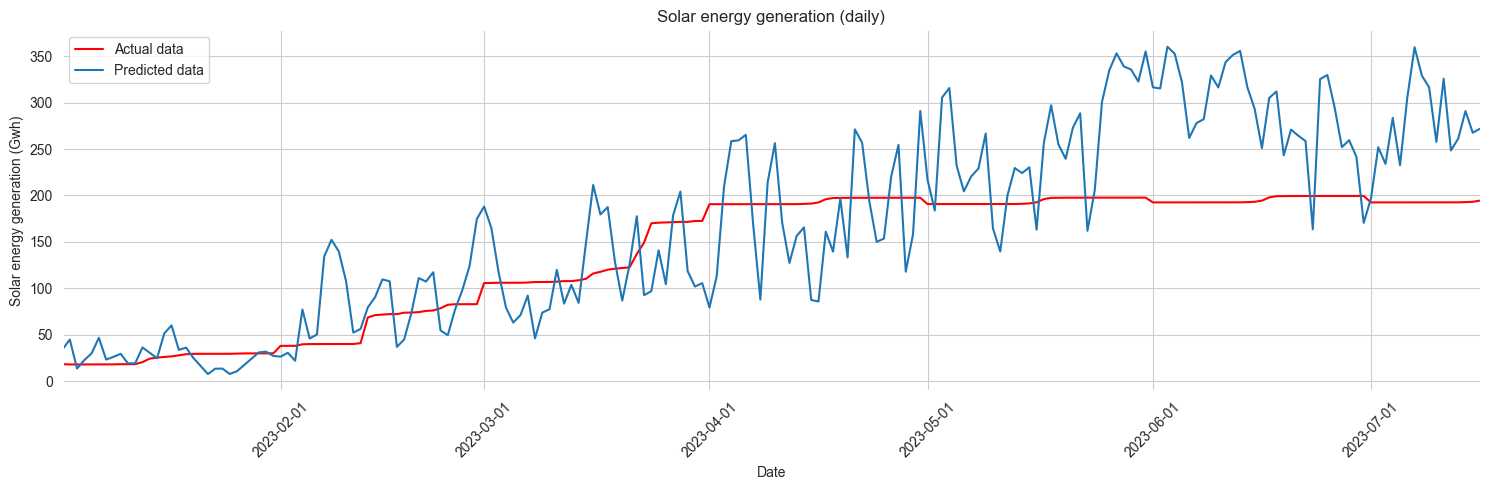

In [405]:
from sklearn.model_selection import GridSearchCV
# Extract features and target variables
features_Uni =  ['Year', 'Month', 'Day']

X_train = train[features_Uni]
X_test = test[features_Uni]
y_train = train[target]
y_test = test[target]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)

# Define hyperparameters for the grid search
param_grid = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=rf_reg, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit the grid search on the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Get the best model from the grid search
best_rf_reg = grid_search.best_estimator_

# Make predictions on the scaled test set
test['prediction'] = best_rf_reg.predict(X_test_scaled)

# Calculate evaluation metrics on the unscaled predictions
mse = mean_squared_error(y_test, test['prediction'])
mae = mean_absolute_error(y_test, test['prediction'])
rmse = mean_squared_error(y_test, test['prediction'], squared=False)
r2 = r2_score(y_test, test['prediction'])

print("Best parameters found during grid search:", grid_search.best_params_)
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)


# Plot actual and predicted data
fig, ax = plt.subplots(figsize=(15,5))
df_dt[target].plot(ax=ax, color='#1f76b4', label='Actual Data')
test['prediction'].plot(ax=ax, color='red', label='Predicted Data', title='')
ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (Gwh)')#(ylable_target)
ax.set_xlabel('Date')
plt.title('Solar energy generation (daily)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calculate residuals
residuals = y_test - test['prediction']
# Create a residual plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title(title_main)
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test['prediction'], label=' ', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label=' ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Solar energy generation (daily)')
#plt.title(title_main)
#plt.legend()
plt.show()


fig, ax = plt.subplots(figsize=(15,5))
test['prediction'].loc[(test['prediction'].index > '2023-01-01') & (test['prediction'].index < '2023-12-01') ].plot(ax=ax, color='red', label='Predicted Data', title='')
df_dt[target].loc[(df_dt[target].index > '2023-01-01') & (df_dt[target].index < '2023-12-01') ].plot(ax=ax, color='#1f76b4', label='Actual Data')
#ax.axvline('2022-01-1', color='black', label='Test/Train Split', ls='--')
ax.legend(['Actual data', 'Predicted data'])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (Gwh)')#(ylable_target)
ax.set_xlabel('Date')
plt.title('Solar energy generation (daily)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- mwh to gwh
- Capitalize column name
- drop drop duplicate columns

#### Weather data information (new daily data)

In [207]:
df_weather_daily_10loc.columns, df_weather_daily_10loc.shape

(Index(['dt_date', 'average_temp_c_sc', 'norm_temp_c_sc', 'max_temp_c_sc',
        'min_temp_c_sc', 'sunshine_hour_sc', 'precipitation_mm_sc',
        'average_wind_speed_mpers_sc', 'dt_date.1', 'average_temp_c_hh',
        'norm_temp_c_hh', 'max_temp_c_hh', 'min_temp_c_hh', 'sunshine_hour_hh',
        'precipitation_mm_hh', 'average_wind_speed_mpers_hh', 'dt_date.2',
        'average_temp_c_bi', 'norm_temp_c_bi', 'max_temp_c_bi', 'min_temp_c_bi',
        'sunshine_hour_bi', 'precipitation_mm_bi',
        'average_wind_speed_mpers_bi', 'dt_date.3', 'average_temp_c_kb',
        'norm_temp_c_kb', 'max_temp_c_kb', 'min_temp_c_kb', 'sunshine_hour_kb',
        'precipitation_mm_kb', 'average_wind_speed_mpers_kb', 'dt_date.4',
        'average_temp_c_go', 'norm_temp_c_go', 'max_temp_c_go', 'min_temp_c_go',
        'sunshine_hour_go', 'precipitation_mm_go',
        'average_wind_speed_mpers_go', 'dt_date.5', 'average_temp_c_dr',
        'norm_temp_c_dr', 'max_temp_c_dr', 'min_temp_c_dr', 'sun

#### Mean average of weather features of 10 different states of Germany

In [208]:
# Define a list of str_start for all the 7 weather features
list_str_start = ['average_temp_c_', 'norm_temp_c_',
       'max_temp_c_', 'min_temp_c_', 'sunshine_hour_',
       'precipitation_mm_', 'average_wind_speed_mpers_']

In [209]:
# Calculate means

# Find all columns that start with str_start
for str_start in list_str_start:
    wf_columns = [col for col in df_weather_daily_10loc.columns if col.startswith(str_start)]

    # Calculate mean
    new_col_name = str_start + 'mean_de'
    df_weather_daily_10loc[new_col_name] = df_weather_daily_10loc[wf_columns].mean(axis=1)

In [210]:
#df_weather_daily_10loc.columns#df_weather_daily_10loc.describe().T

In [211]:
df_weather_daily_10loc.columns = [col.capitalize() for col in df_weather_daily_10loc.columns]
df_weather_daily_10loc.rename(columns = {'Dt_date': 'Date'}, inplace = True)  
df_weather_daily_10loc.head()
# Print the dataframe
#df_weather_daily_10loc.head()

,Date,Average_temp_c_sc,Norm_temp_c_sc,Max_temp_c_sc,Min_temp_c_sc,Sunshine_hour_sc,Precipitation_mm_sc,Average_wind_speed_mpers_sc,Dt_date.1,Average_temp_c_hh,...,Sunshine_hour_mu,Precipitation_mm_mu,Average_wind_speed_mpers_mu,Average_temp_c_mean_de,Norm_temp_c_mean_de,Max_temp_c_mean_de,Min_temp_c_mean_de,Sunshine_hour_mean_de,Precipitation_mm_mean_de,Average_wind_speed_mpers_mean_de
0,2015-01-01,3.5,1.1,4.4,2.7,1.0,1.2,6.7,2015-01-01,3.6,...,3.8,0.0,1.6,0.29,1.30,3.01,-2.42,3.22,1.37,2.88
1,2015-01-02,5.8,1.2,8.8,3.8,0.3,0.6,10.4,2015-01-02,6.3,...,2.4,5.6,4.1,2.94,1.27,6.15,-0.80,0.61,4.59,5.36
2,2015-01-03,3.7,0.9,5.0,2.1,0.0,4.2,8.4,2015-01-03,4.5,...,0.1,26.4,3.0,2.92,1.21,5.12,1.22,0.01,8.43,4.39
3,2015-01-04,3.3,0.9,5.0,2.1,3.7,0.0,5.8,2015-01-04,4.0,...,0.0,0.0,6.2,2.52,1.36,4.69,0.82,2.15,0.19,4.29
4,2015-01-05,4.1,0.7,4.7,3.0,0.0,0.1,5.6,2015-01-05,3.8,...,1.6,0.0,4.1,1.48,1.15,3.75,-0.56,2.49,0.15,3.22


In [212]:
#df_weather_daily_10loc.columns, df_weather_daily_10loc.shape

In [213]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
#main_0  = 'Total_energy_generation_gwh' # This is only for energy
main_0  = 'Solar_gwh' # for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'energy generation (daily)')# for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'

#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'

# here we set the ylabel
ylable_0  = target.replace('_gwh', ' energy generation (GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Solar energy generation (daily)
Solar energy generation (GWh)


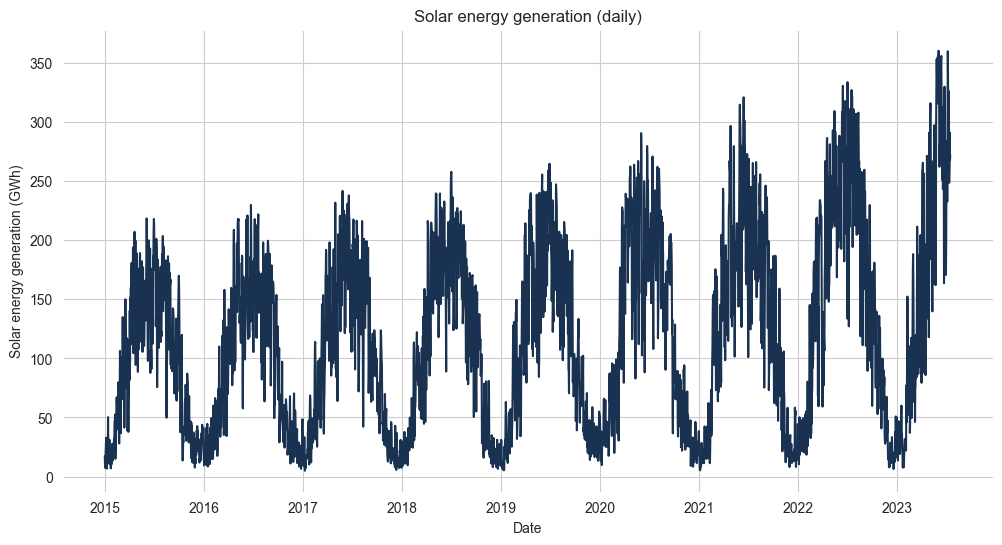

In [214]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=df_daily, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

#### Merging  daily energy production with weather data (We will keep only columns of interest from both dataframes)

- Merging the daily energy generation data  with weather informations

In [215]:
start_date= '2015-01-01'
end_date = '2023-07-16'

weather_July = df_weather_daily_10loc[(df_weather_daily_10loc['Date'] >= start_date) & (df_weather_daily_10loc['Date'] <= end_date)]
# Create a new DataFrame with the filtered data and only the required columns

weather_July_df = pd.DataFrame(weather_July)
weather_July_df.reset_index(drop=True, inplace=True)

In [216]:
weather_July_df.shape, df_daily.shape#weather_July_df.head()

((3119, 87), (3119, 37))

In [217]:
 df_daily.columns

Index(['Dt_date_hour', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Total_energy_generation_mwh', 'Dt_year', 'Dt_month', 'Dt_week',
       'Dt_dayofweek', 'Dt_dayofmonth', 'Dt_dayofyear', 'Dt_monthname',
       'Dt_dayname', 'Date', 'Solar_gwh', 'Total_energy_generation_gwh',
       'Year', 'Month', 'Day'],
      dtype='object')

In [218]:
#df_weather_daily_10loc
#df_daily

#columns_keep_df_weather = ['Average_temp_c_mu', 'Norm_temp_c_mu',	'Max_temp_c_mu','Min_temp_c_mu', 'Sunshine_hour_mu', 'Precipitation_mm_mu', 'Average_wind_speed_mpers_mu']
columns_keep_df_daily = ['Date', 'Solar_gwh', 'Total_energy_generation_gwh']
daily_df_N = df_daily[columns_keep_df_daily].copy()

columns_keep_df_weather_daily = ['Date','Average_wind_speed_mpers_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de','Sunshine_hour_mean_de', 'Precipitation_mm_mean_de']

weather_July_df_N = weather_July_df[columns_keep_df_weather_daily].copy()

In [219]:
daily_df_N.head()

,Date,Solar_gwh,Total_energy_generation_gwh
0,2015-01-01,17.08025,1271.68350
1,2015-01-02,7.75900,1493.59800
2,2015-01-03,7.23475,1408.94650
3,2015-01-04,19.98250,1325.84900
4,2015-01-05,26.52225,1521.12275


In [220]:
weather_July_df_N.head()

,Date,Average_wind_speed_mpers_mean_de,Average_temp_c_mean_de,Norm_temp_c_mean_de,Max_temp_c_mean_de,Min_temp_c_mean_de,Sunshine_hour_mean_de,Precipitation_mm_mean_de
0,2015-01-01,2.88,0.29,1.30,3.01,-2.42,3.22,1.37
1,2015-01-02,5.36,2.94,1.27,6.15,-0.80,0.61,4.59
2,2015-01-03,4.39,2.92,1.21,5.12,1.22,0.01,8.43
3,2015-01-04,4.29,2.52,1.36,4.69,0.82,2.15,0.19
4,2015-01-05,3.22,1.48,1.15,3.75,-0.56,2.49,0.15


In [221]:
daily_df_N['Date'] = pd.to_datetime(daily_df_N['Date'], format='%Y-%m-%d')
weather_July_df_N['Date'] = pd.to_datetime(weather_July_df_N['Date'], format='%Y-%m-%d')

In [222]:
weather_July_df_N.head()

,Date,Average_wind_speed_mpers_mean_de,Average_temp_c_mean_de,Norm_temp_c_mean_de,Max_temp_c_mean_de,Min_temp_c_mean_de,Sunshine_hour_mean_de,Precipitation_mm_mean_de
0,2015-01-01,2.88,0.29,1.30,3.01,-2.42,3.22,1.37
1,2015-01-02,5.36,2.94,1.27,6.15,-0.80,0.61,4.59
2,2015-01-03,4.39,2.92,1.21,5.12,1.22,0.01,8.43
3,2015-01-04,4.29,2.52,1.36,4.69,0.82,2.15,0.19
4,2015-01-05,3.22,1.48,1.15,3.75,-0.56,2.49,0.15


In [223]:
daily_df_N.head()

,Date,Solar_gwh,Total_energy_generation_gwh
0,2015-01-01,17.08025,1271.68350
1,2015-01-02,7.75900,1493.59800
2,2015-01-03,7.23475,1408.94650
3,2015-01-04,19.98250,1325.84900
4,2015-01-05,26.52225,1521.12275


In [224]:
# Merge the dataframes on the 'Date' column
daily_weather_df = weather_July_df_N.merge(daily_df_N, on=['Date'])

In [225]:
daily_weather_df.shape, daily_weather_df.columns

((3119, 10),
 Index(['Date', 'Average_wind_speed_mpers_mean_de', 'Average_temp_c_mean_de',
        'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de',
        'Sunshine_hour_mean_de', 'Precipitation_mm_mean_de', 'Solar_gwh',
        'Total_energy_generation_gwh'],
       dtype='object'))

In [226]:
daily_weather_df.head()

,Date,Average_wind_speed_mpers_mean_de,Average_temp_c_mean_de,Norm_temp_c_mean_de,Max_temp_c_mean_de,Min_temp_c_mean_de,Sunshine_hour_mean_de,Precipitation_mm_mean_de,Solar_gwh,Total_energy_generation_gwh
0,2015-01-01,2.88,0.29,1.30,3.01,-2.42,3.22,1.37,17.08025,1271.68350
1,2015-01-02,5.36,2.94,1.27,6.15,-0.80,0.61,4.59,7.75900,1493.59800
2,2015-01-03,4.39,2.92,1.21,5.12,1.22,0.01,8.43,7.23475,1408.94650
3,2015-01-04,4.29,2.52,1.36,4.69,0.82,2.15,0.19,19.98250,1325.84900
4,2015-01-05,3.22,1.48,1.15,3.75,-0.56,2.49,0.15,26.52225,1521.12275


In [227]:
columns_mlvt_daily=['Date','Average_wind_speed_mpers_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de','Sunshine_hour_mean_de', 'Precipitation_mm_mean_de', 'Solar_gwh']
#target = 'Total_energy_generation_gwh'
data_mlvt_daily = daily_weather_df[columns_mlvt_daily].copy()
data_mlvt_daily.head()


,Date,Average_wind_speed_mpers_mean_de,Average_temp_c_mean_de,Norm_temp_c_mean_de,Max_temp_c_mean_de,Min_temp_c_mean_de,Sunshine_hour_mean_de,Precipitation_mm_mean_de,Solar_gwh
0,2015-01-01,2.88,0.29,1.30,3.01,-2.42,3.22,1.37,17.08025
1,2015-01-02,5.36,2.94,1.27,6.15,-0.80,0.61,4.59,7.75900
2,2015-01-03,4.39,2.92,1.21,5.12,1.22,0.01,8.43,7.23475
3,2015-01-04,4.29,2.52,1.36,4.69,0.82,2.15,0.19,19.98250
4,2015-01-05,3.22,1.48,1.15,3.75,-0.56,2.49,0.15,26.52225


In [236]:
columns_date_target=['Date', 'Solar_gwh']
df_plot = df_daily[columns_date_target].copy()
df_c = df_daily[columns_date_target].copy()

<Axes: xlabel='Date'>

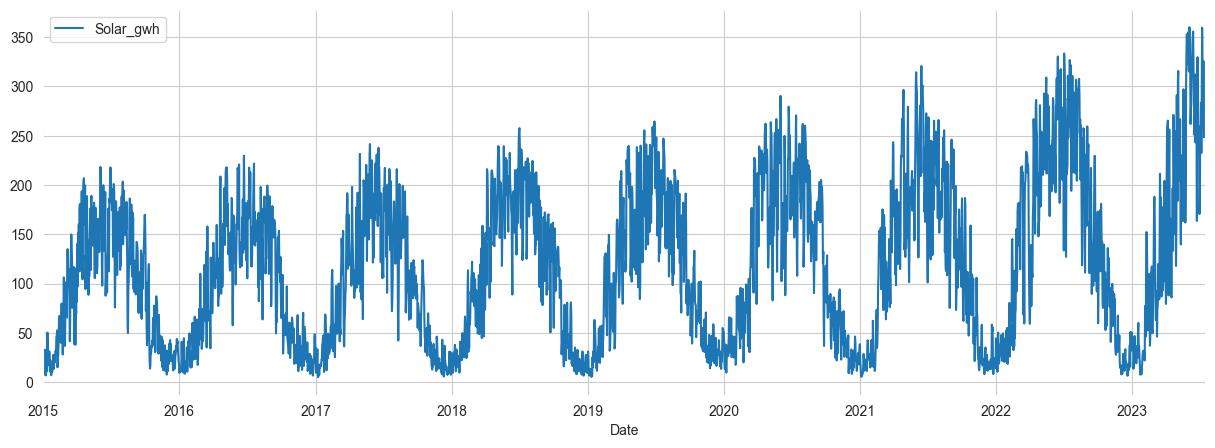

In [237]:
df_c = df_c.set_index('Date')
df_c.plot(style = '-', figsize = (15,5), color='#1f76b4')

In [238]:
df_c.index, df_c.index.values

(DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
                '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
                '2015-01-09', '2015-01-10',
                ...
                '2023-07-07', '2023-07-08', '2023-07-09', '2023-07-10',
                '2023-07-11', '2023-07-12', '2023-07-13', '2023-07-14',
                '2023-07-15', '2023-07-16'],
               dtype='datetime64[ns]', name='Date', length=3119, freq=None),
 array(['2015-01-01T00:00:00.000000000', '2015-01-02T00:00:00.000000000',
        '2015-01-03T00:00:00.000000000', ...,
        '2023-07-14T00:00:00.000000000', '2023-07-15T00:00:00.000000000',
        '2023-07-16T00:00:00.000000000'], dtype='datetime64[ns]'))

In [239]:
df_c.columns, df_plot.columns

(Index(['Solar_gwh'], dtype='object'),
 Index(['Date', 'Solar_gwh'], dtype='object'))

In [241]:
#features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
features=  ['Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'

In [191]:

X_train = features
X_test = test[features]

y_train = train
y_test = test

In [179]:
#y_train.head()

In [138]:
#data_mlvt_daily.head()



## XGboost regressor for  daily data forecast

In [244]:
#features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
features =  ['Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'

RMSE: 28.162721120033066
MAE: 20.923391484560113
MSE: 793.1388608847565
R2 Score: 0.8745238416623857


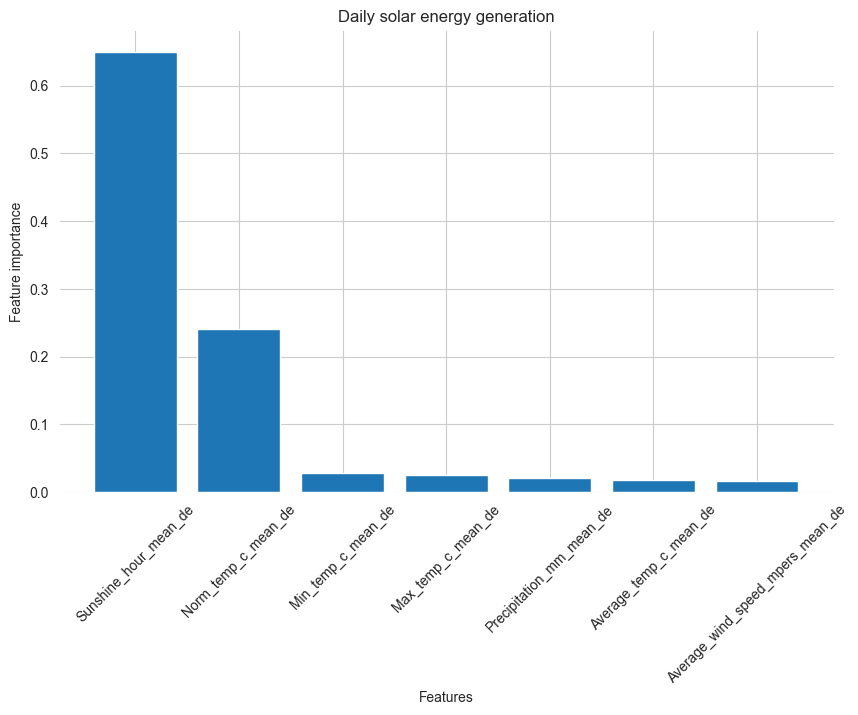

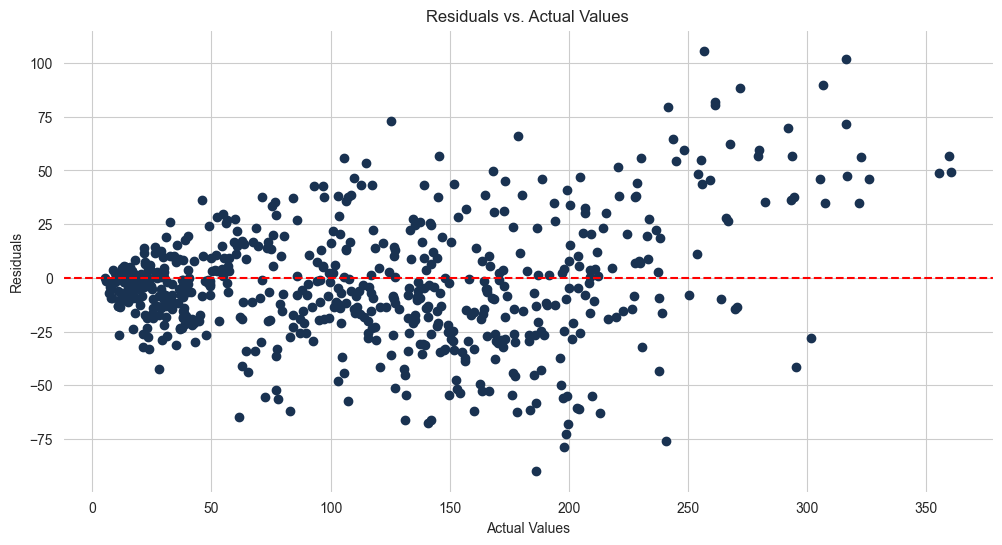

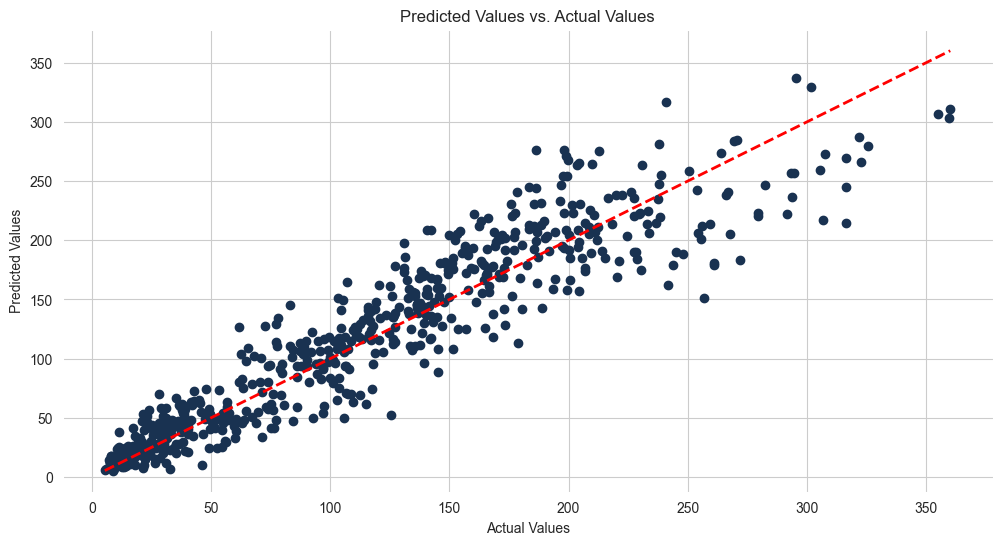

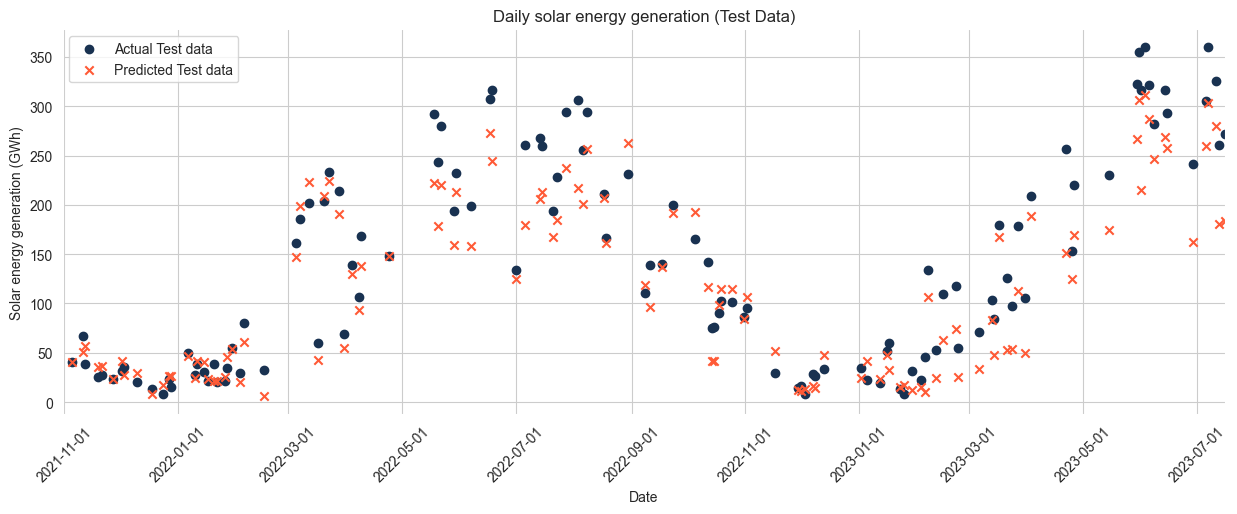

In [320]:
features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
#features =  ['Sunshine_hour_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'

# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the XGBoost model
#model = xgb.XGBRegressor()
model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)


# Get feature importances
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Daily solar energy generation')
#plt.xlabel("Feature")
#plt.ylabel("Feature Importance")
#plt.title("Feature Importance")
plt.show()

# Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.show()

# Create a predicted vs actual plot
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values")
plt.show()

# Plot test and predicted values for test data
fig, ax = plt.subplots(figsize=(15,5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 80% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data)')
plt.legend()
plt.show()

#fig, ax = plt.subplots(figsize=(15, 5))
# Plot actual train data and predicted train data
#plt.scatter(data_mlvt_daily['Date'].iloc[X_train.index], y_train, label='Actual Train data', marker='o')
#plt.scatter(data_mlvt_daily['Date'].iloc[X_train.index], model.predict(X_train_scaled), label='Predicted Train data', marker='x')
# Set x-axis limits to start from the beginning and end at the train-test split point
#end_idx = int(len(data_mlvt_daily) * 0.8)
#plt.xlim(data_mlvt_daily['Date'].iloc[0], data_mlvt_daily['Date'].iloc[end_idx])
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
#ax.set_ylabel('Solar energy generation (GWh)')
#ax.set_xlabel('Date')
#plt.xticks(rotation=45)
#plt.title('Daily solar energy generation (Train Data)')
#plt.legend()
#plt.show()




RMSE: 31.983461607046657
MAE: 22.66779617414719
MSE: 1022.9418163694276
R2 Score: 0.8381685532622174


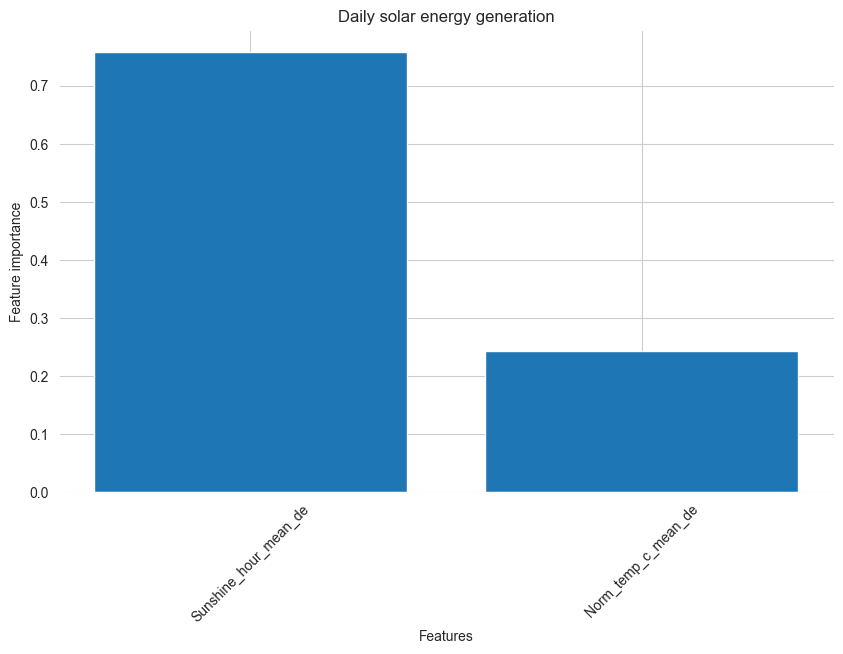

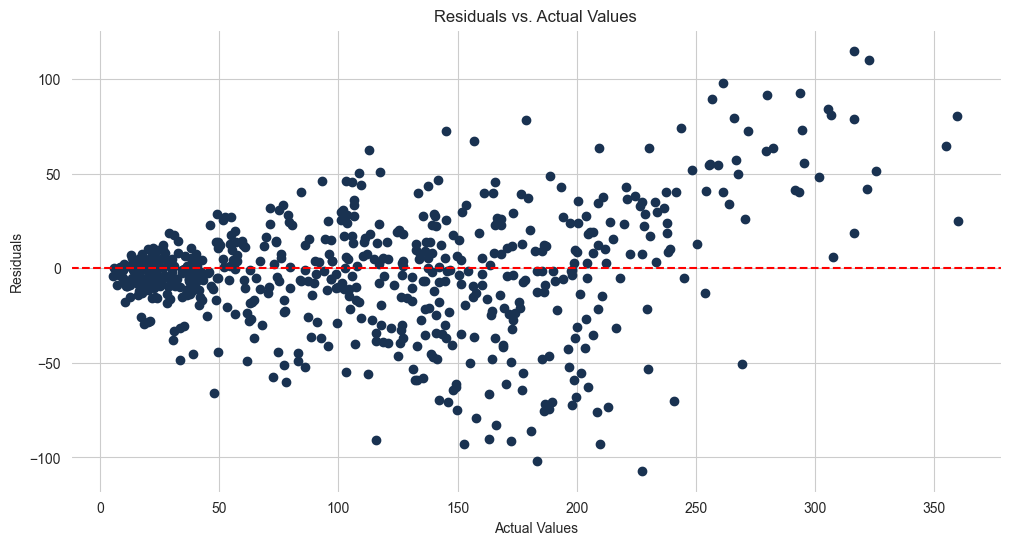

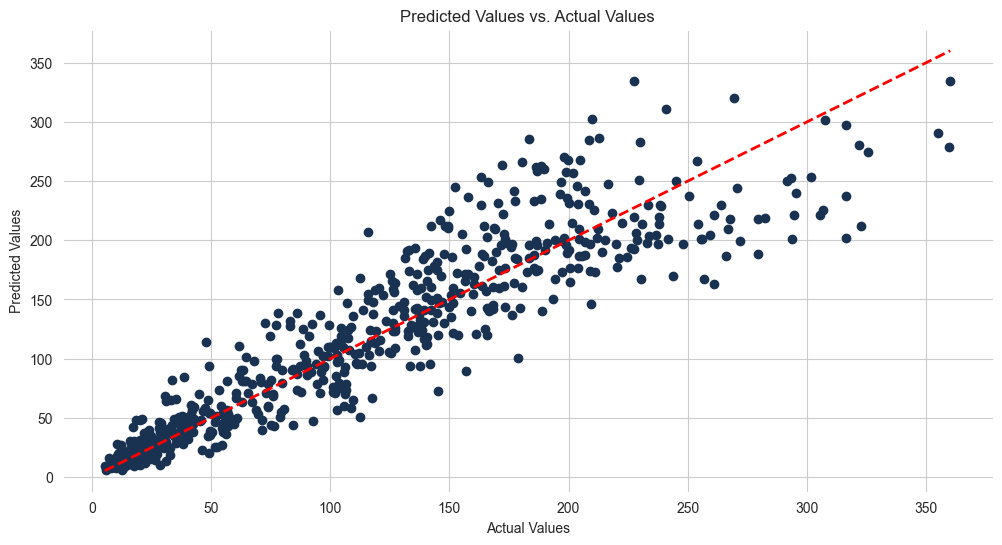

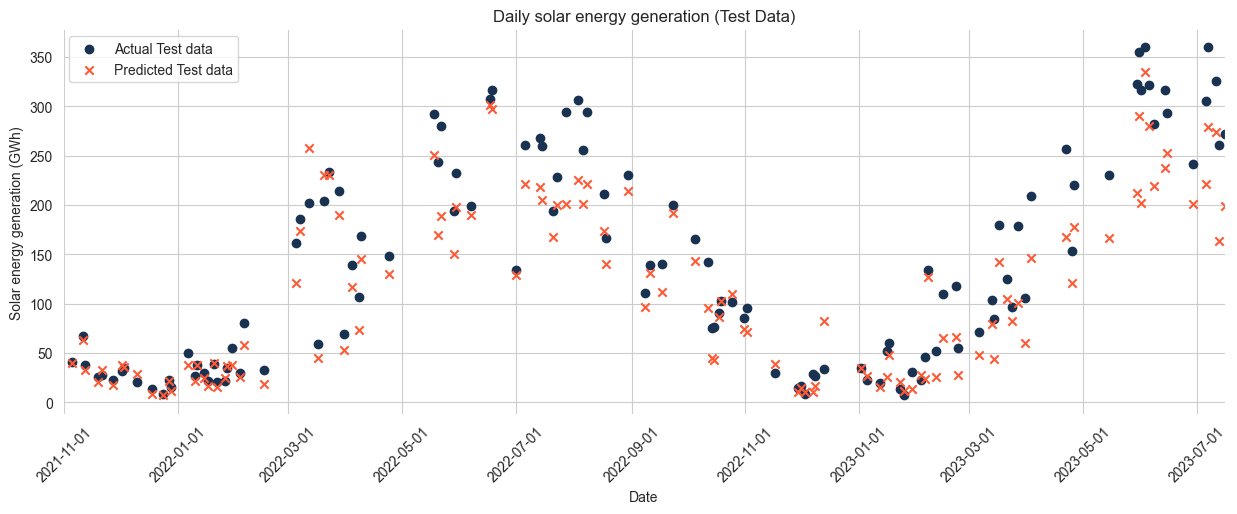

In [321]:
features=  ['Sunshine_hour_mean_de',  'Norm_temp_c_mean_de']#, 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
#features =  ['Sunshine_hour_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'

# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the XGBoost model
#model = xgb.XGBRegressor()
model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)


# Get feature importances
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Daily solar energy generation')
#plt.xlabel("Feature")
#plt.ylabel("Feature Importance")
#plt.title("Feature Importance")
plt.show()

# Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.show()

# Create a predicted vs actual plot
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values")
plt.show()

# Plot test and predicted values for test data
fig, ax = plt.subplots(figsize=(15,5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 20% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data)')
plt.legend()
plt.show()

#fig, ax = plt.subplots(figsize=(15, 5))
# Plot actual train data and predicted train data
#plt.scatter(data_mlvt_daily['Date'].iloc[X_train.index], y_train, label='Actual Train data', marker='o')
#plt.scatter(data_mlvt_daily['Date'].iloc[X_train.index], model.predict(X_train_scaled), label='Predicted Train data', marker='x')
# Set x-axis limits to start from the beginning and end at the train-test split point
#end_idx = int(len(data_mlvt_daily) * 0.8)
#plt.xlim(data_mlvt_daily['Date'].iloc[0], data_mlvt_daily['Date'].iloc[end_idx])
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
#ax.set_ylabel('Solar energy generation (GWh)')
#ax.set_xlabel('Date')
#plt.xticks(rotation=45)
#plt.title('Daily solar energy generation (Train Data)')
#plt.legend()
#plt.show()




RMSE: 44.061806035488694
MAE: 33.354720555757865
MSE: 1941.4427511090278
R2 Score: 0.692859863442039


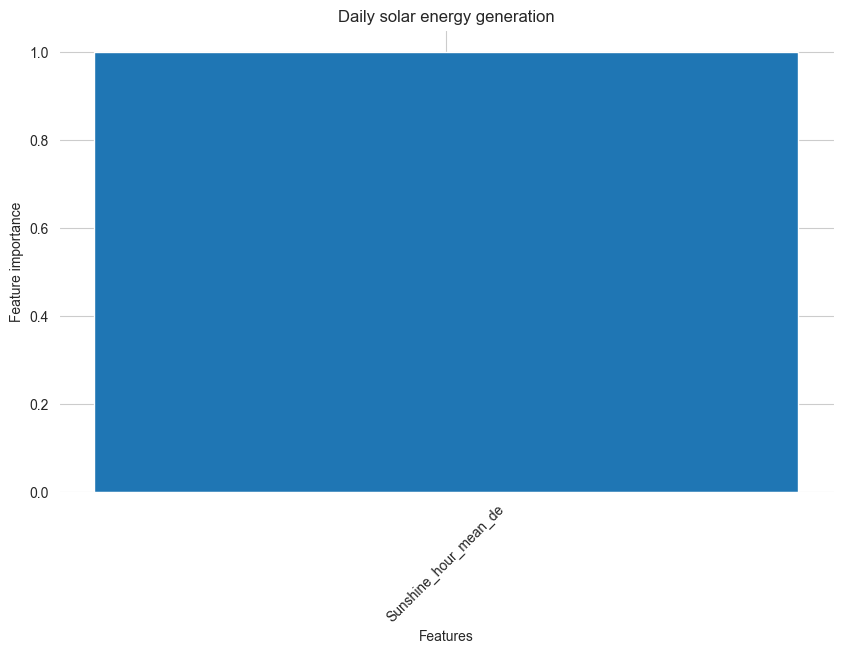

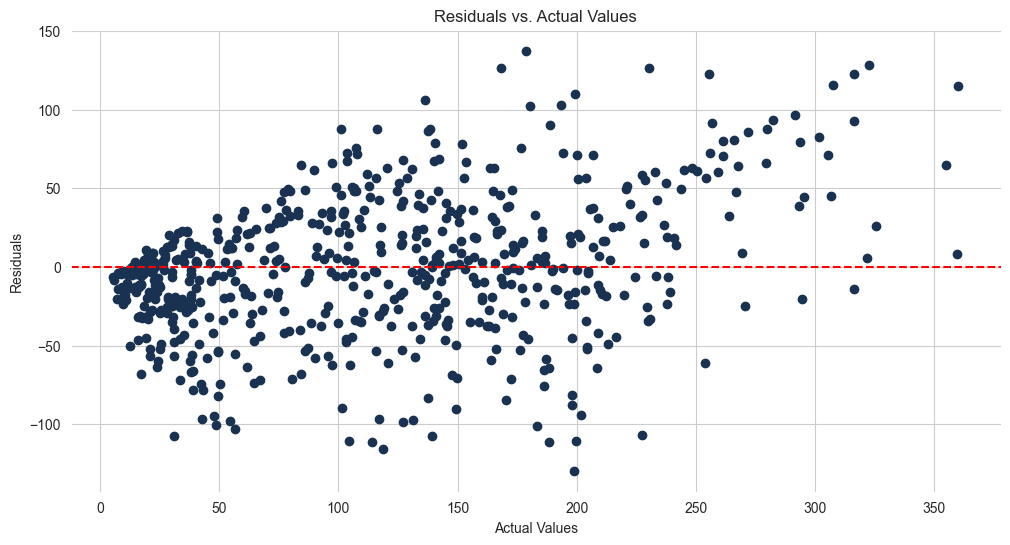

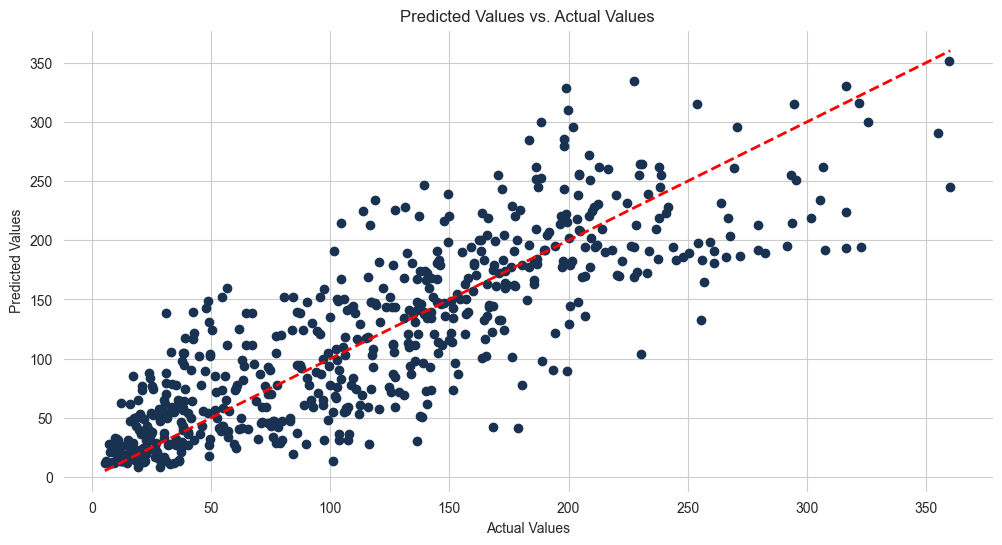

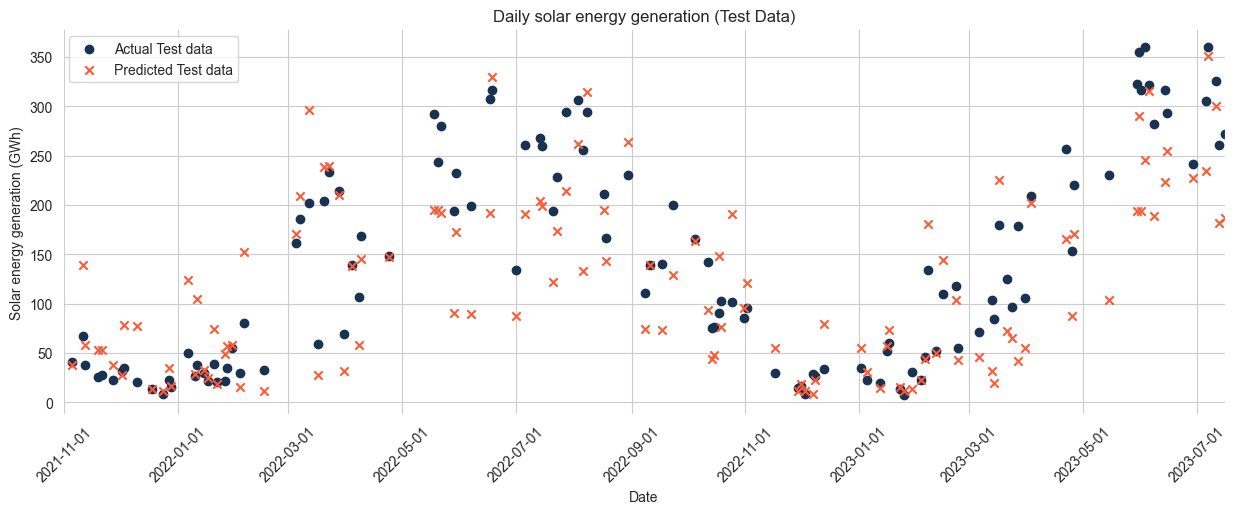

In [322]:
#features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
features =  ['Sunshine_hour_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'

# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the XGBoost model
#model = xgb.XGBRegressor()
model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)


# Get feature importances
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Daily solar energy generation')
#plt.xlabel("Feature")
#plt.ylabel("Feature Importance")
#plt.title("Feature Importance")
plt.show()

# Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.show()

# Create a predicted vs actual plot
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values")
plt.show()

# Plot test and predicted values for test data
fig, ax = plt.subplots(figsize=(15,5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 20% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data)')
plt.legend()
plt.show()

#fig, ax = plt.subplots(figsize=(15, 5))
# Plot actual train data and predicted train data
#plt.scatter(data_mlvt_daily['Date'].iloc[X_train.index], y_train, label='Actual Train data', marker='o')
#plt.scatter(data_mlvt_daily['Date'].iloc[X_train.index], model.predict(X_train_scaled), label='Predicted Train data', marker='x')
# Set x-axis limits to start from the beginning and end at the train-test split point
#end_idx = int(len(data_mlvt_daily) * 0.8)
#plt.xlim(data_mlvt_daily['Date'].iloc[0], data_mlvt_daily['Date'].iloc[end_idx])
#plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
#ax.set_ylabel('Solar energy generation (GWh)')
#ax.set_xlabel('Date')
#plt.xticks(rotation=45)
#plt.title('Daily solar energy generation (Train Data)')
#plt.legend()
#plt.show()




RMSE: 40.25308118013014
MAE: 29.538218545950375
MSE: 1620.310544494147
R2 Score: 0.7436636225209565


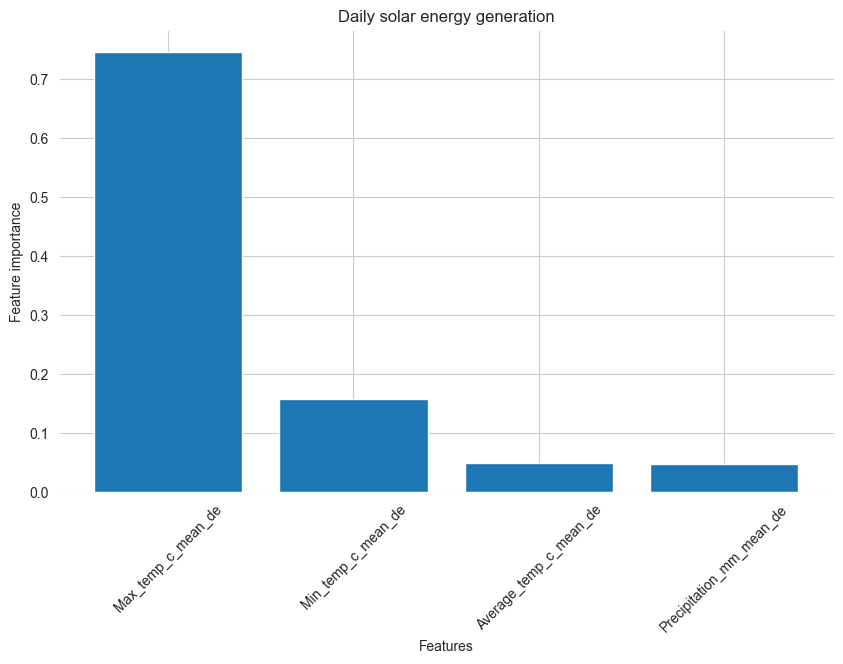

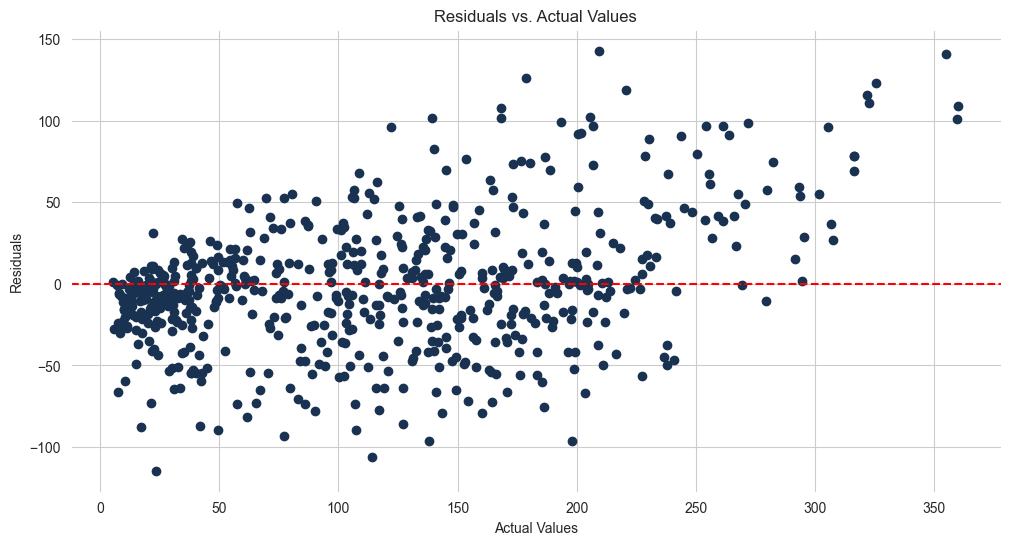

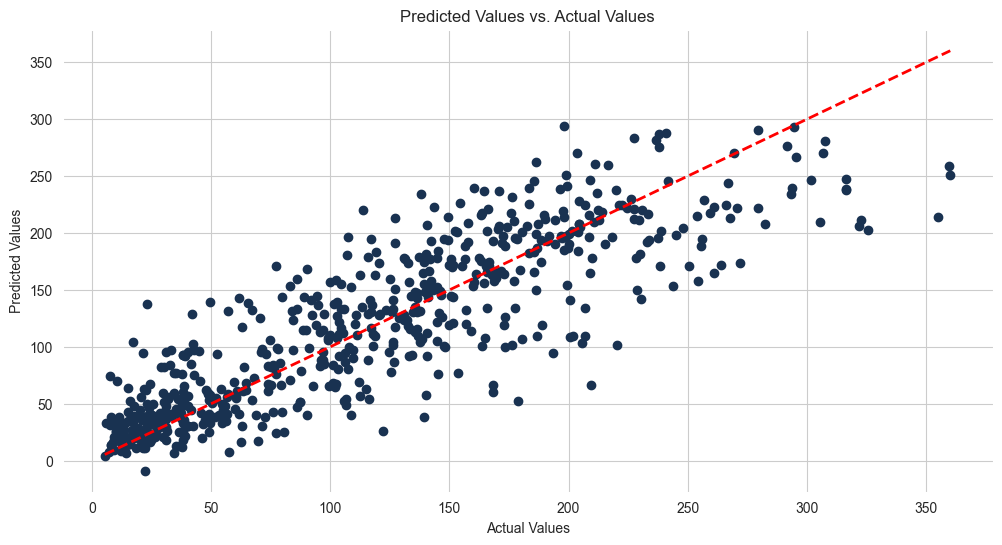

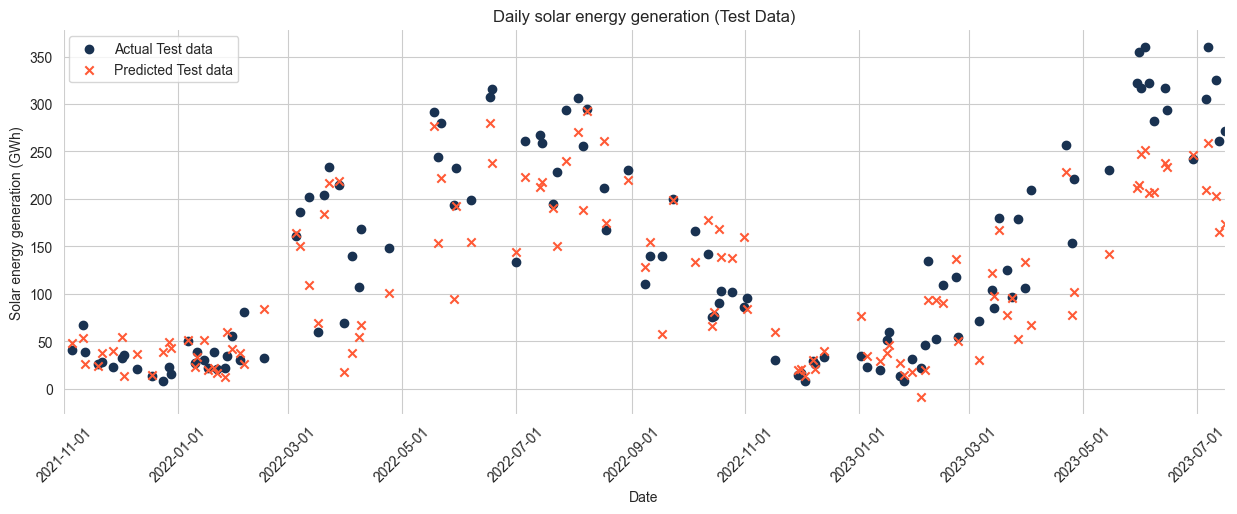

In [323]:
#features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
features =  ['Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'

# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the XGBoost model
#model = xgb.XGBRegressor()
model = xgb.XGBRegressor(n_estimators=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)


# Get feature importances
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Daily solar energy generation')
#plt.xlabel("Feature")
#plt.ylabel("Feature Importance")
#plt.title("Feature Importance")
plt.show()

# Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.show()

# Create a predicted vs actual plot
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values")
plt.show()




# Plot test and predicted values for test data
fig, ax = plt.subplots(figsize=(15,5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 20% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data)')
plt.legend()
plt.show()


## Grid search CV for XG boost 

Best Model Evaluation:
RMSE: 26.557484173642855
MAE: 20.0839936830678
MSE: 705.2999656332906
R2 Score: 0.8884201310416241


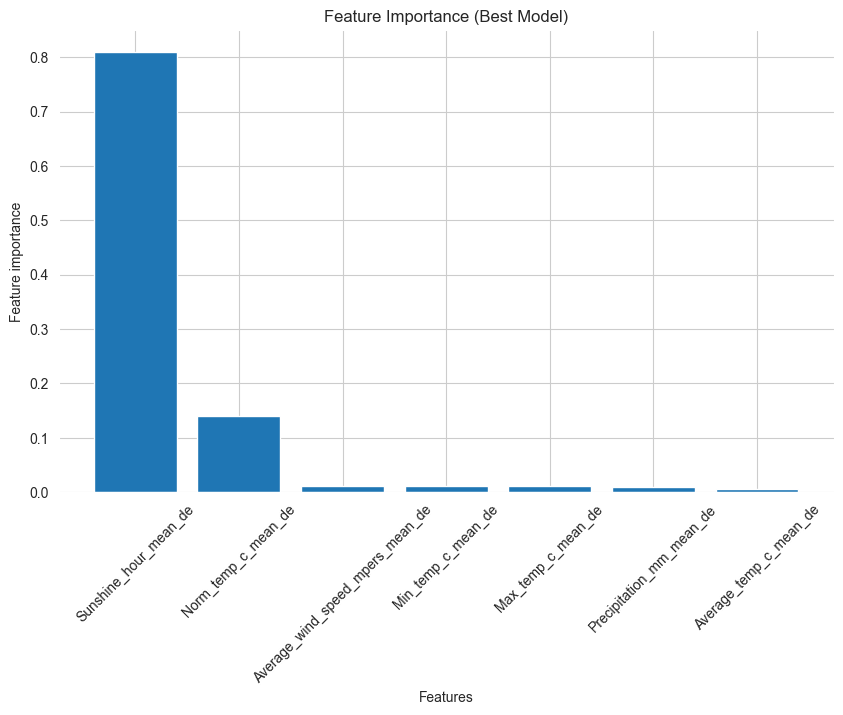

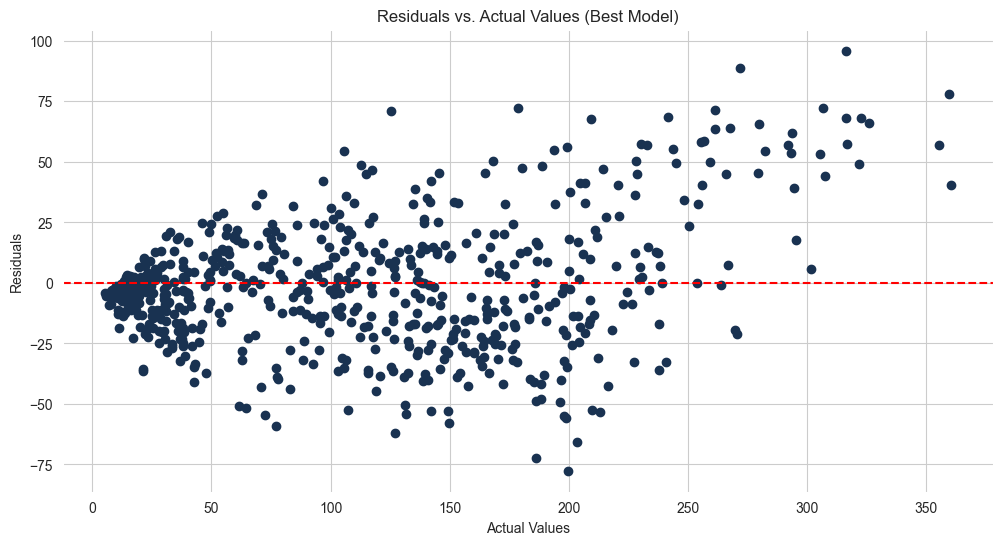

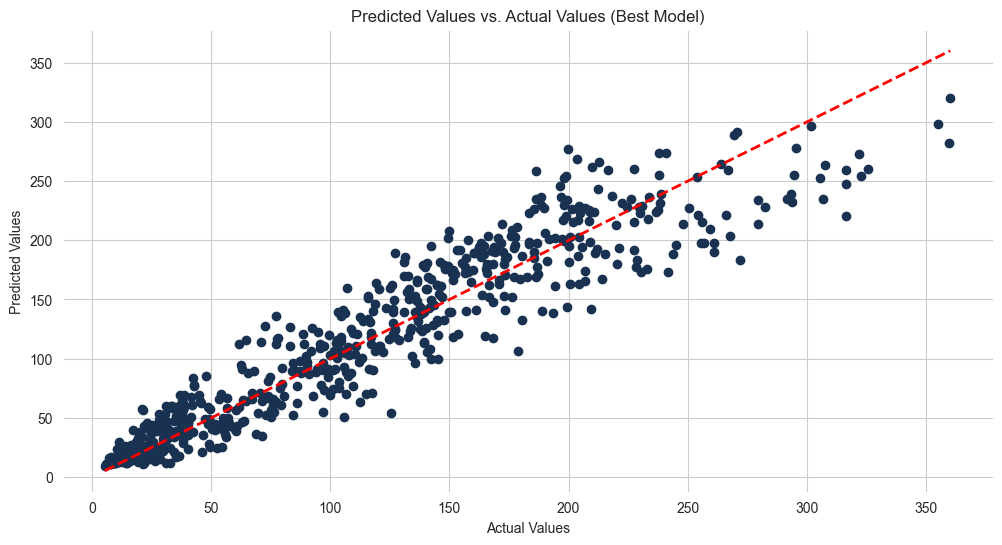

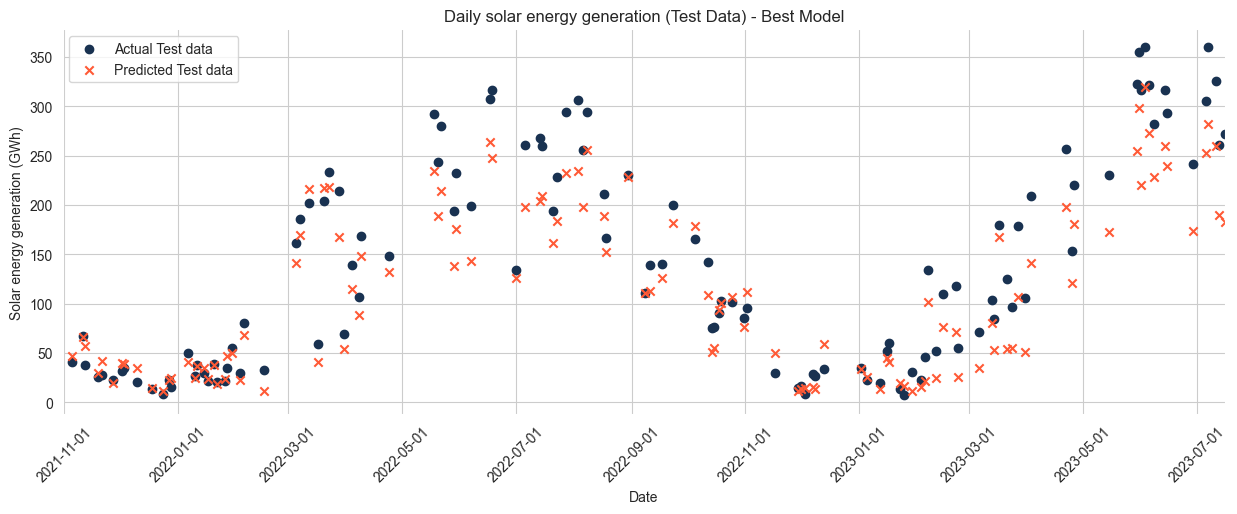

In [333]:
from sklearn.model_selection import GridSearchCV#, train_test_split
# Features and target columns
features = ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de',
            'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'

# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a Random Forest model
base_model = RandomForestRegressor(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the GridSearchCV object on the data
grid_search.fit(X_train_scaled, y_train)

# Get the best model and its parameters
best_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_best = best_model.predict(X_test_scaled)

# Calculate evaluation metrics for the best model
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Best Model Evaluation:")
print("RMSE:", rmse_best)
print("MAE:", mae_best)
print("MSE:", mse_best)
print("R2 Score:", r2_best)

# Get feature importances
feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance for the best model
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Feature Importance (Best Model)')
plt.show()

# Create a residual plot for the best model
residuals_best = y_test - y_pred_best
plt.scatter(y_test, residuals_best)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values (Best Model)")
plt.show()

# Create a predicted vs actual plot for the best model
plt.scatter(y_test, y_pred_best)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values (Best Model)")
plt.show()

# Plot test and predicted values for test data using the best model
fig, ax = plt.subplots(figsize=(15, 5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred_best, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 80% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data) - Best Model')
plt.legend()
plt.show()


Best Model Evaluation:
RMSE: 35.68628680766227
MAE: 27.579122045714346
MSE: 1273.5110661187302
R2 Score: 0.7985279954650513


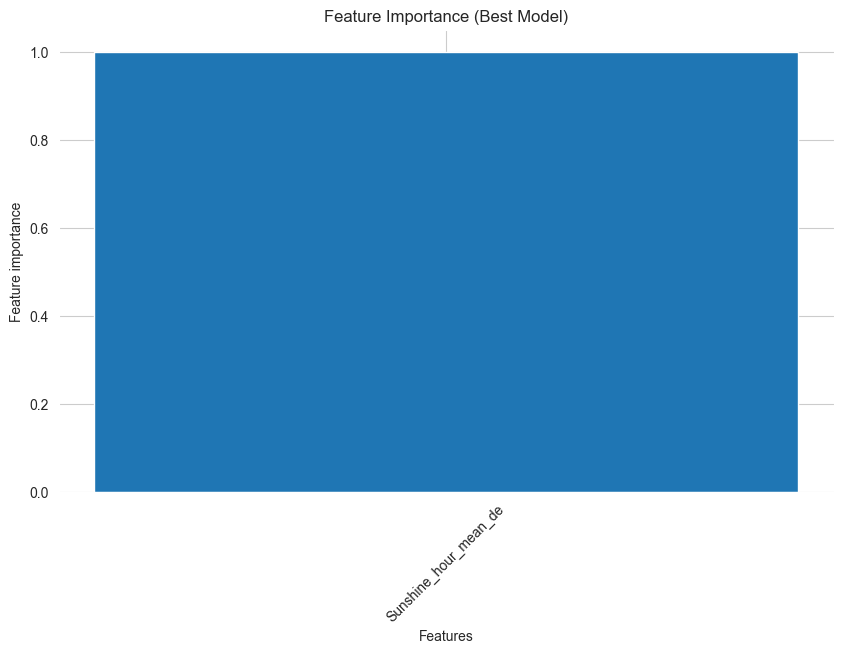

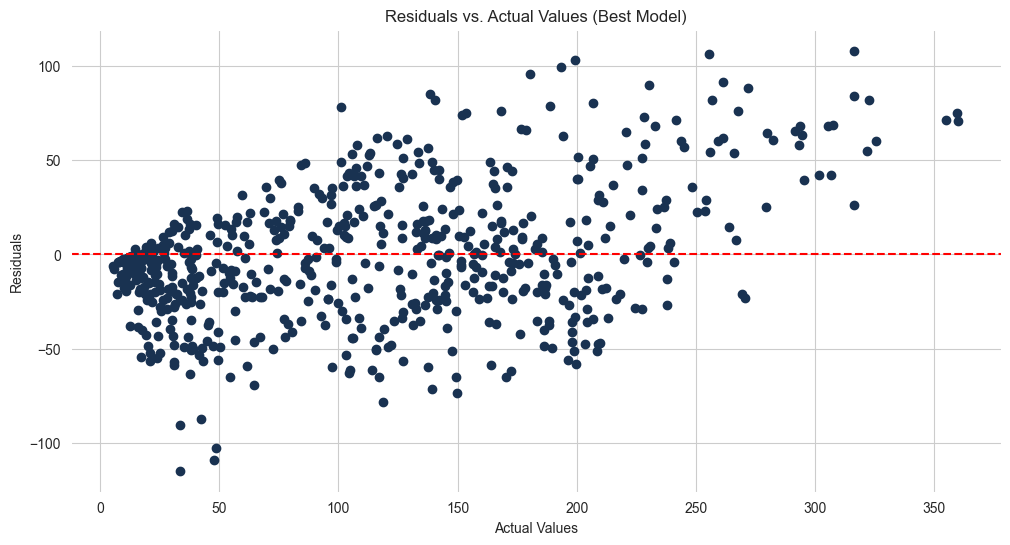

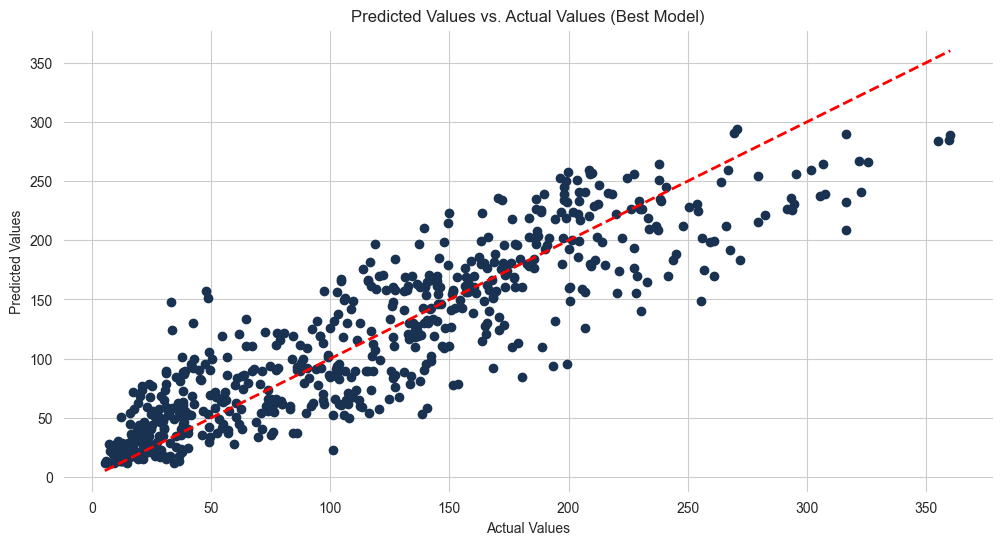

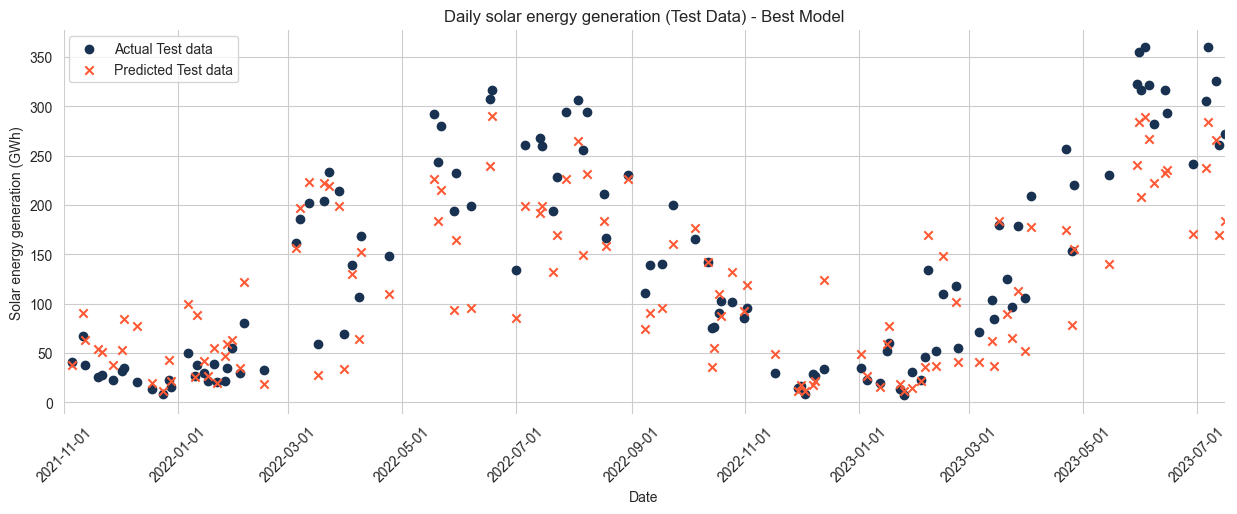

In [334]:
from sklearn.model_selection import GridSearchCV#, train_test_split
# Features and target columns
features = ['Sunshine_hour_mean_de']#, 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de',
 #           'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'

# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a Random Forest model
base_model = RandomForestRegressor(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the GridSearchCV object on the data
grid_search.fit(X_train_scaled, y_train)

# Get the best model and its parameters
best_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_best = best_model.predict(X_test_scaled)

# Calculate evaluation metrics for the best model
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Best Model Evaluation:")
print("RMSE:", rmse_best)
print("MAE:", mae_best)
print("MSE:", mse_best)
print("R2 Score:", r2_best)

# Get feature importances
feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance for the best model
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Feature Importance (Best Model)')
plt.show()

# Create a residual plot for the best model
residuals_best = y_test - y_pred_best
plt.scatter(y_test, residuals_best)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values (Best Model)")
plt.show()

# Create a predicted vs actual plot for the best model
plt.scatter(y_test, y_pred_best)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values (Best Model)")
plt.show()

# Plot test and predicted values for test data using the best model
fig, ax = plt.subplots(figsize=(15, 5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred_best, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 80% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data) - Best Model')
plt.legend()
plt.show()


#### Random forest regressor for daily data production

RMSE: 26.863628457457253
MAE: 20.269855197516016
MSE: 721.6545339003072
R2 Score: 0.8858328055446407


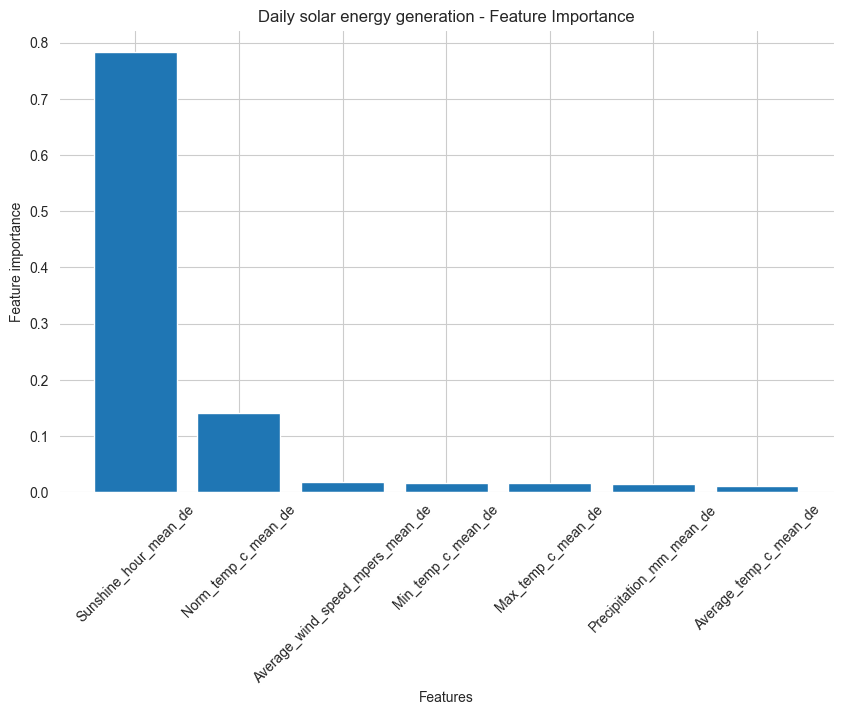

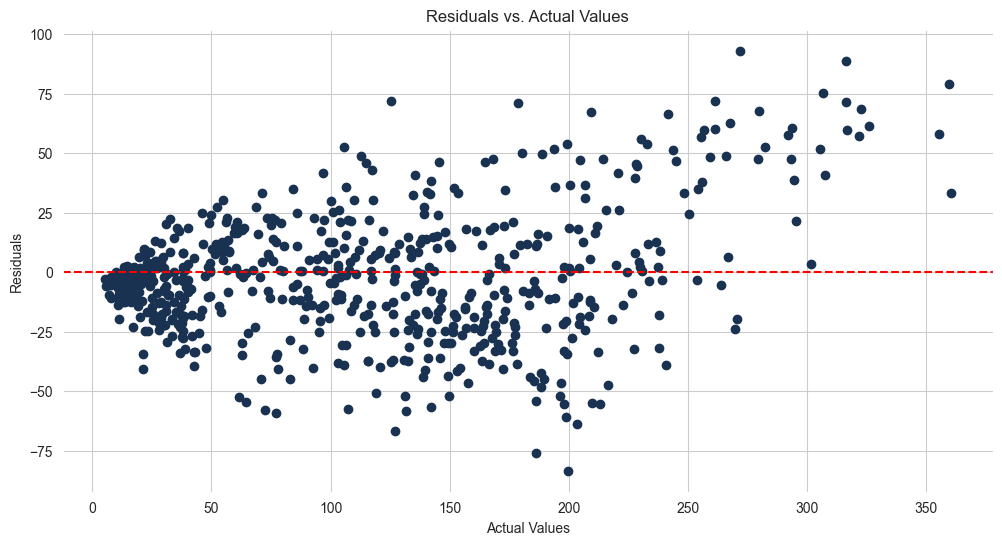

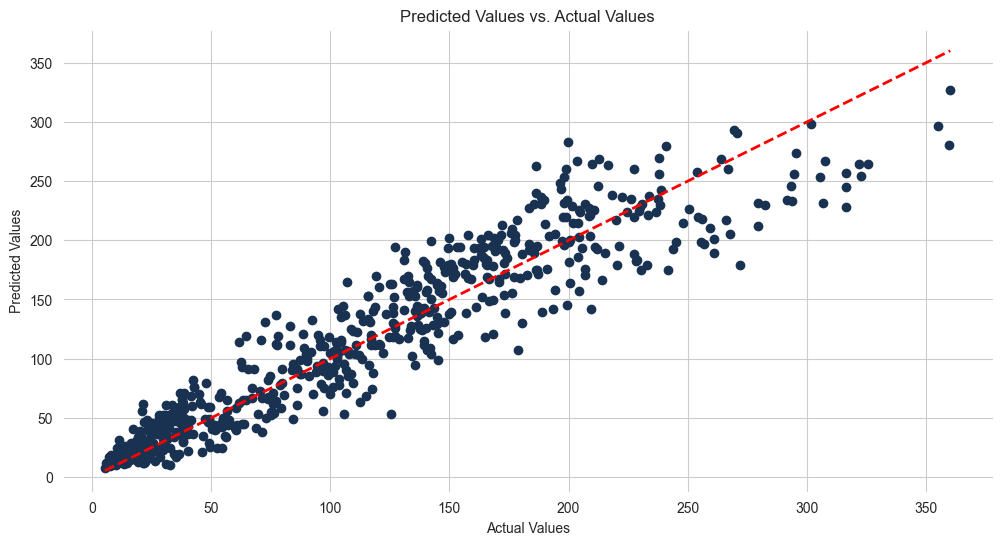

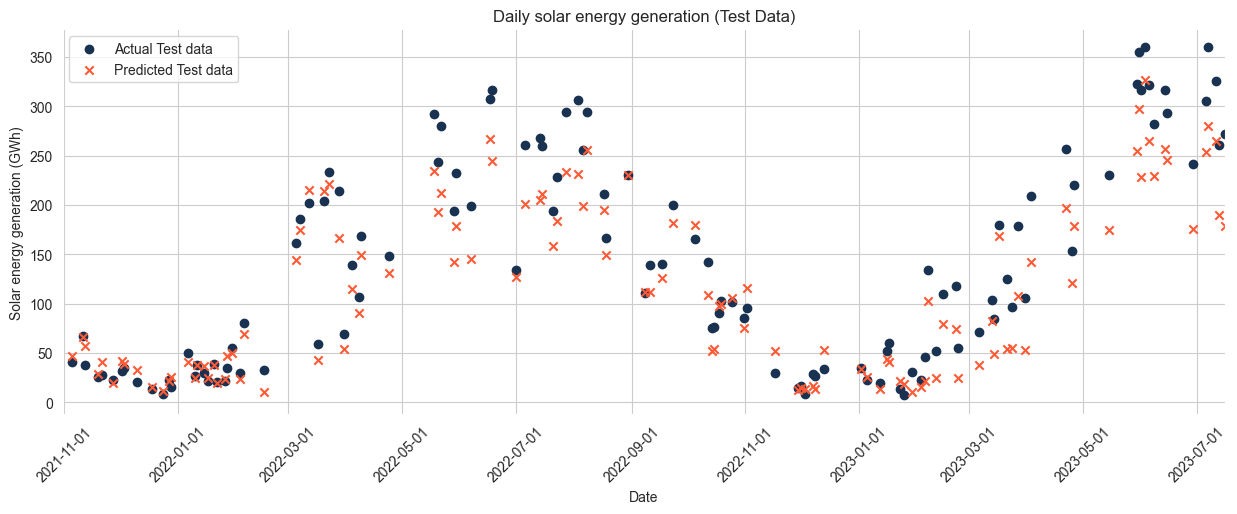

In [326]:
features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
#features =  ['Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'


# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Random Forest model
model = RandomForestRegressor(n_estimators=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

# Get feature importances
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Daily solar energy generation - Feature Importance')
plt.show()

# Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.show()

# Create a predicted vs actual plot
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values")
plt.show()

# Plot test and predicted values for test data
fig, ax = plt.subplots(figsize=(15, 5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 80% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data)')
plt.legend()
plt.show()


RMSE: 40.172634283400605
MAE: 30.769655056394814
MSE: 1613.8405452678535
R2 Score: 0.74468718937337


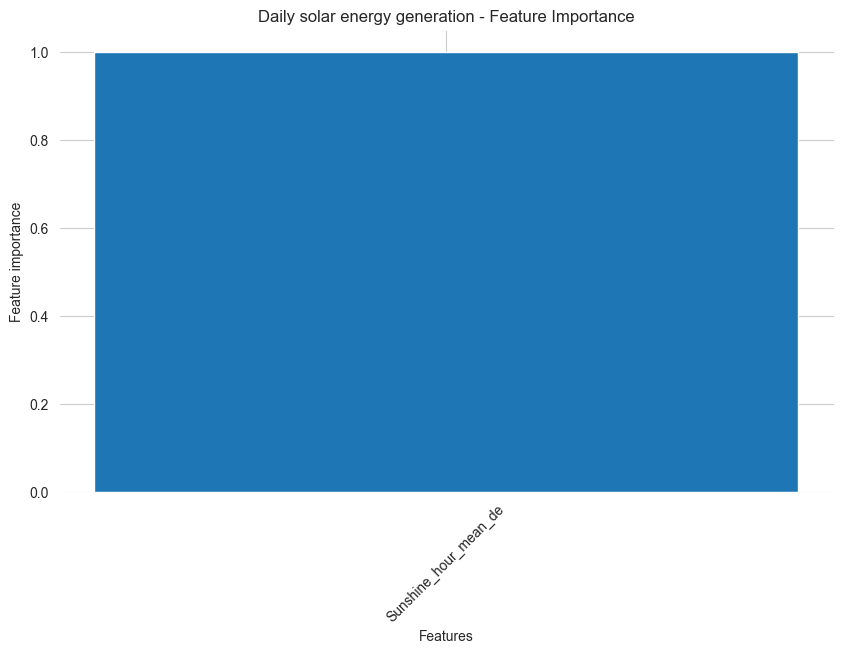

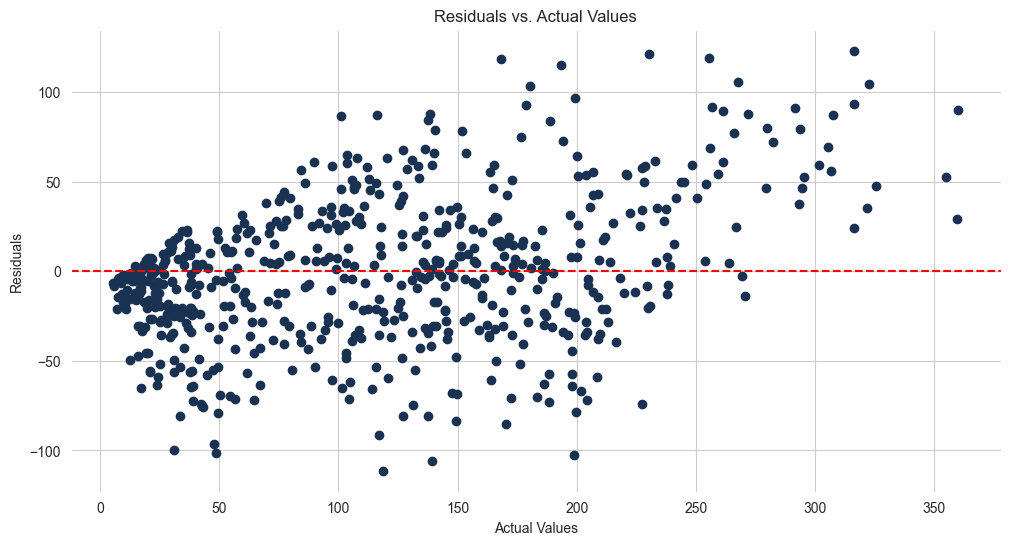

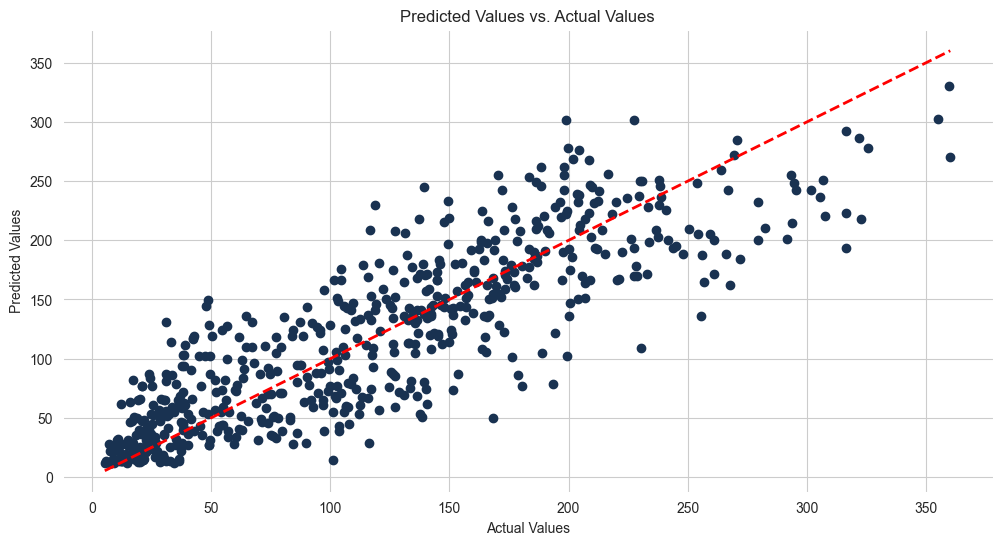

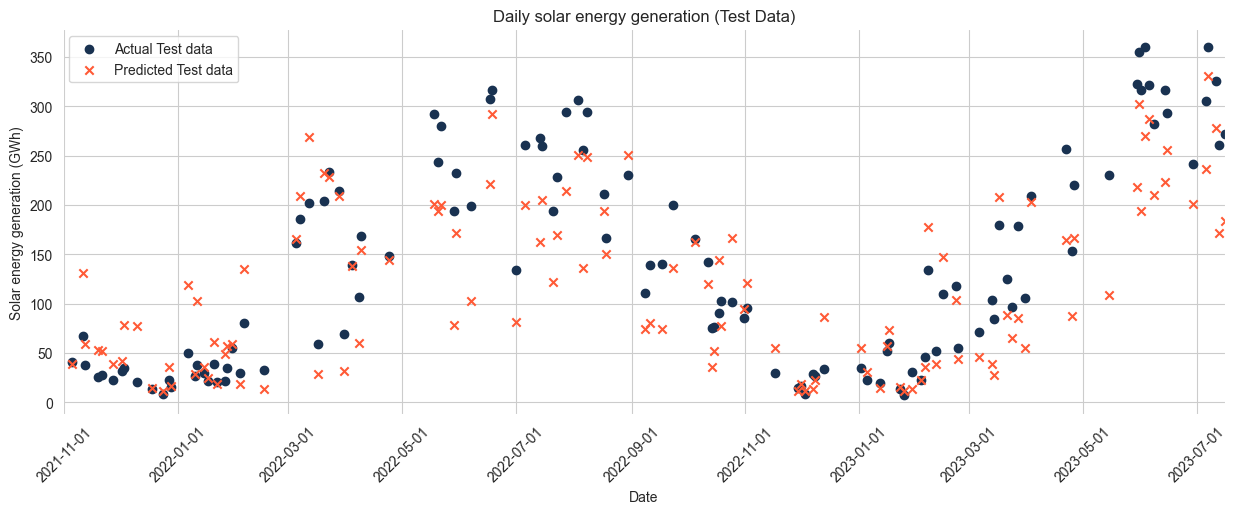

In [327]:
#features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
features = ['Sunshine_hour_mean_de'] #['Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'


# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Random Forest model
model = RandomForestRegressor(n_estimators=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

# Get feature importances
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Daily solar energy generation - Feature Importance')
plt.show()

# Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.show()

# Create a predicted vs actual plot
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values")
plt.show()

# Plot test and predicted values for test data
fig, ax = plt.subplots(figsize=(15, 5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 80% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data)')
plt.legend()
plt.show()


RMSE: 29.702912025067118
MAE: 22.1170274636428
MSE: 882.2629827688768
R2 Score: 0.8604242268524923


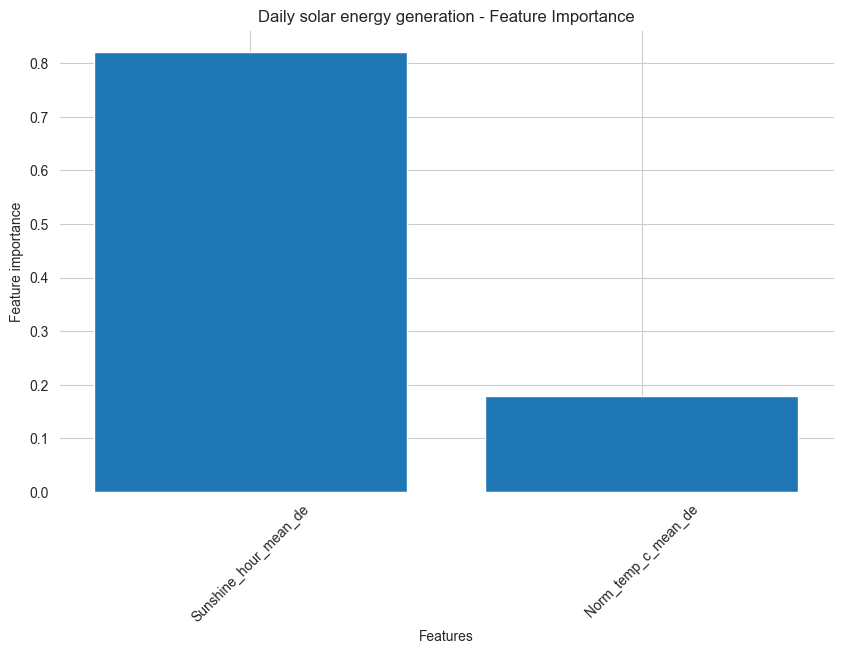

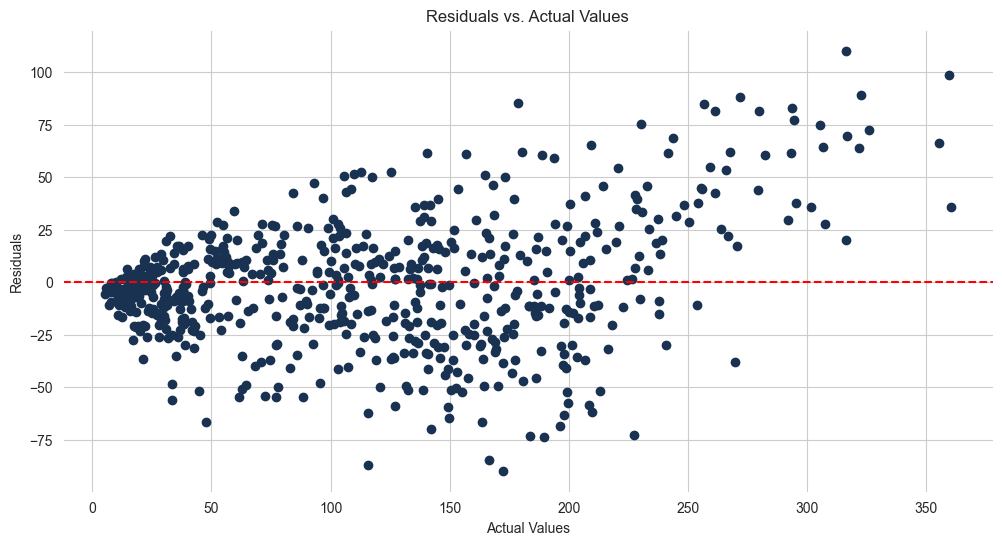

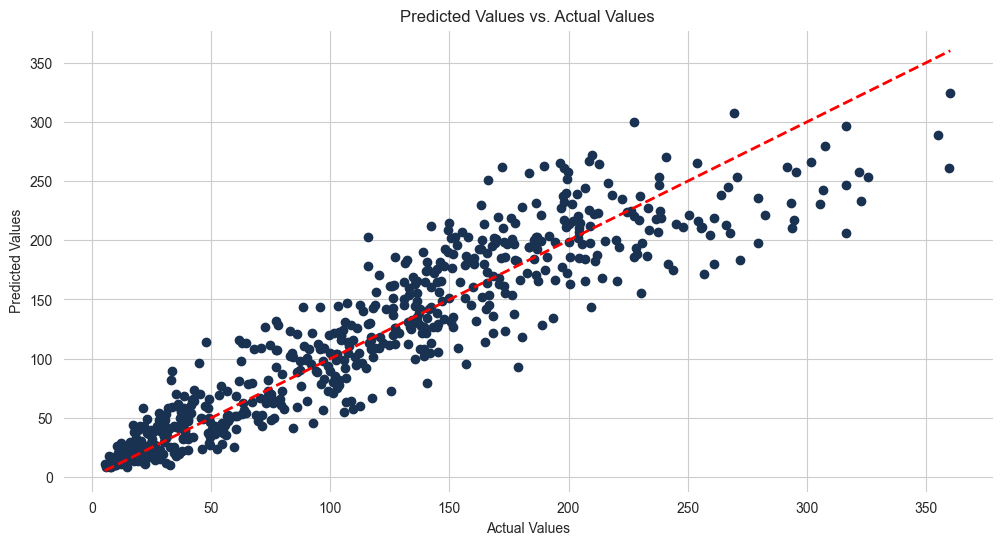

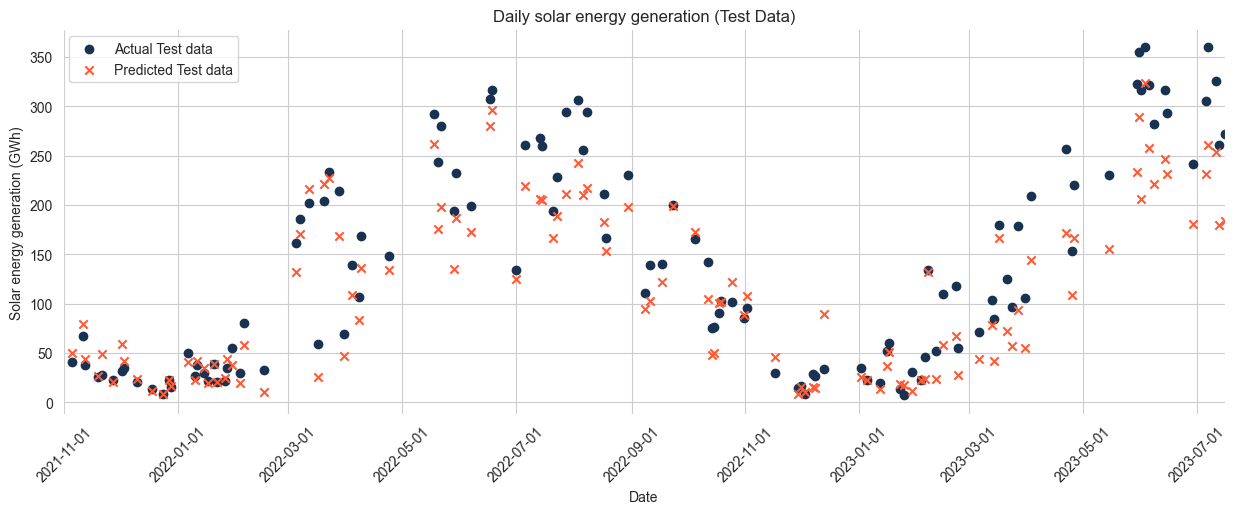

In [328]:
#features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
features = ['Sunshine_hour_mean_de' , 'Norm_temp_c_mean_de'] #['Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'


# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Random Forest model
model = RandomForestRegressor(n_estimators=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

# Get feature importances
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importances[sorted_idx], color='#1f76b4')
plt.xticks(range(X_train_scaled.shape[1]), np.array(features)[sorted_idx], rotation=45)
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.title('Daily solar energy generation - Feature Importance')
plt.show()

# Create a residual plot
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.show()

# Create a predicted vs actual plot
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values")
plt.show()

# Plot test and predicted values for test data
fig, ax = plt.subplots(figsize=(15, 5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 80% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data)')
plt.legend()
plt.show()


In [ ]:
^

#### Grid search for random forest 

In [330]:
features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
#features =  ['Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
target = 'Solar_gwh'


# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 300}
Best Model Evaluation:
RMSE: 27.6000330145081
MAE: 21.11864559765649
MSE: 761.761822401937
R2 Score: 0.8794877520732863


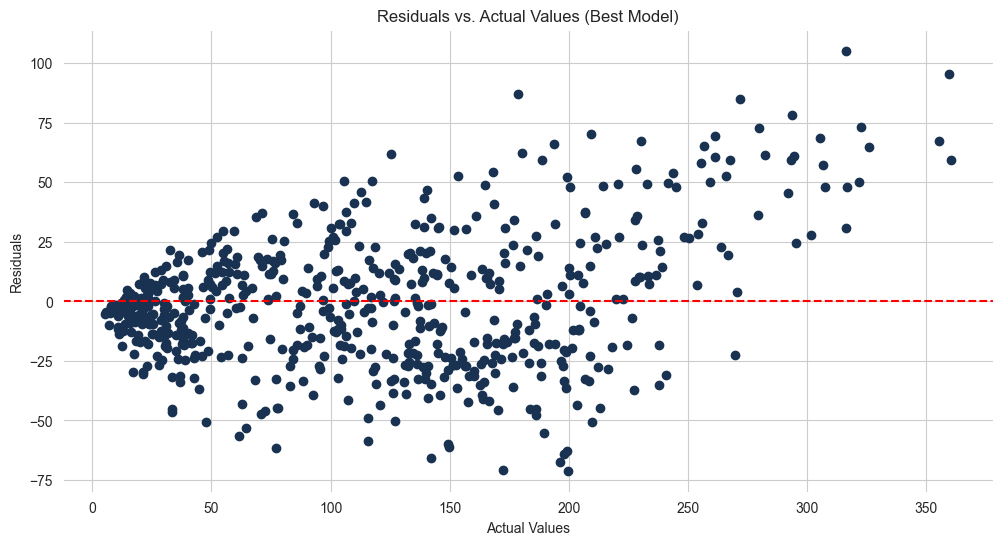

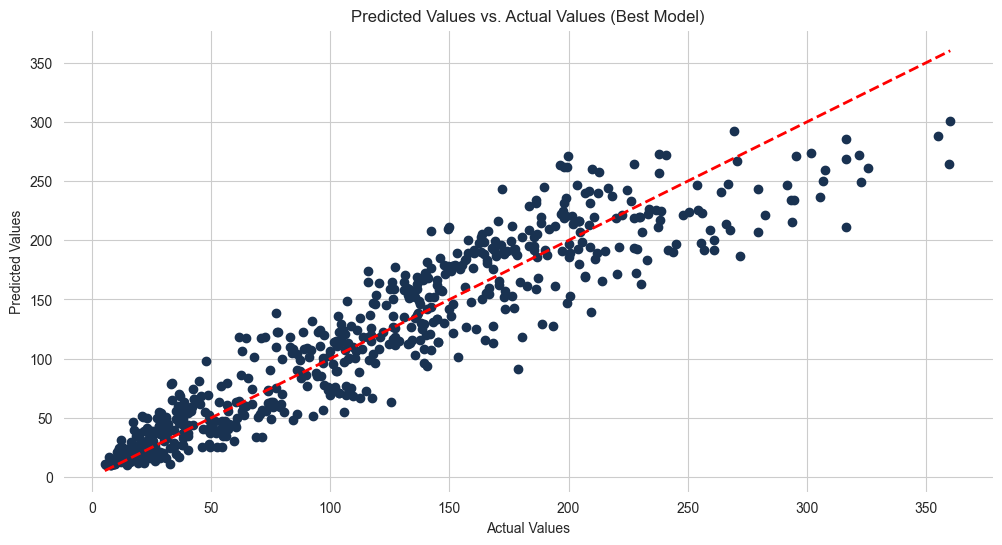

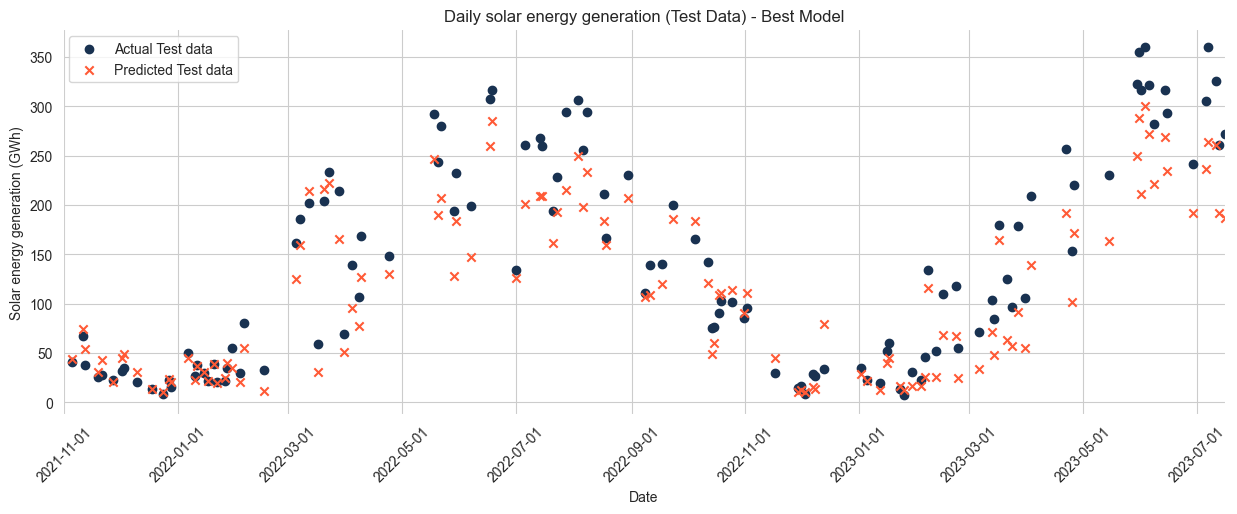

In [332]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [None, 10, 20, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Create a Random Forest model
base_model = RandomForestRegressor(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the GridSearchCV object on the data
grid_search.fit(X_train_scaled, y_train)

# Get the best model and its parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Hyperparameters:", best_params)

# Make predictions on the test set using the best model
y_pred_best = best_model.predict(X_test_scaled)

# Calculate evaluation metrics for the best model
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Best Model Evaluation:")
print("RMSE:", rmse_best)
print("MAE:", mae_best)
print("MSE:", mse_best)
print("R2 Score:", r2_best)




# Create a residual plot for the best model
residuals_best = y_test - y_pred_best
plt.scatter(y_test, residuals_best)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values (Best Model)")
plt.show()

# Create a predicted vs actual plot for the best model
plt.scatter(y_test, y_pred_best)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values (Best Model)")
plt.show()

# Plot test and predicted values for test data using the best model
fig, ax = plt.subplots(figsize=(15, 5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred_best, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 80% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data) - Best Model')
plt.legend()
plt.show()


Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 1000}
Best Model Evaluation:
RMSE: 34.87607423614387
MAE: 26.894374652483194
MSE: 1216.3405541250186
R2 Score: 0.8075724851111181


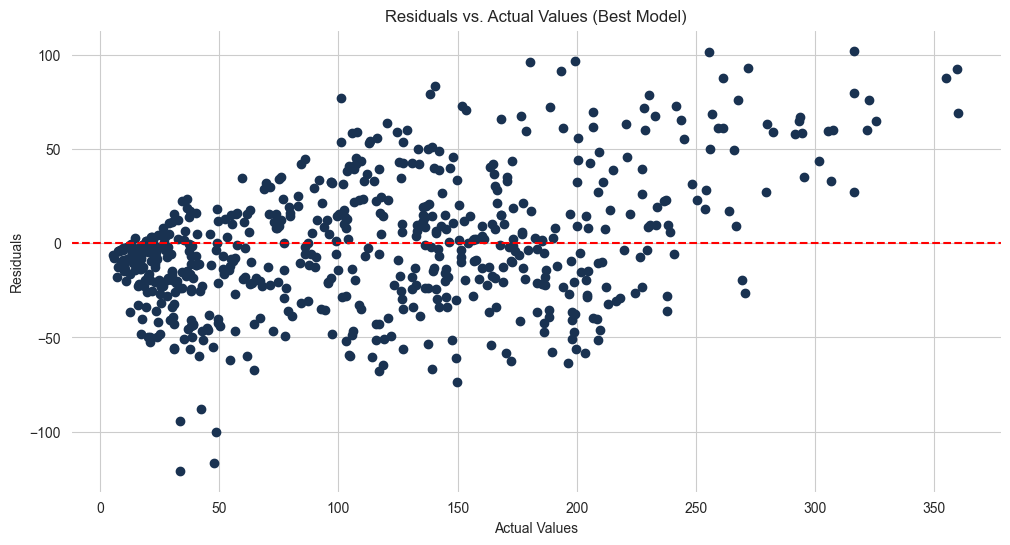

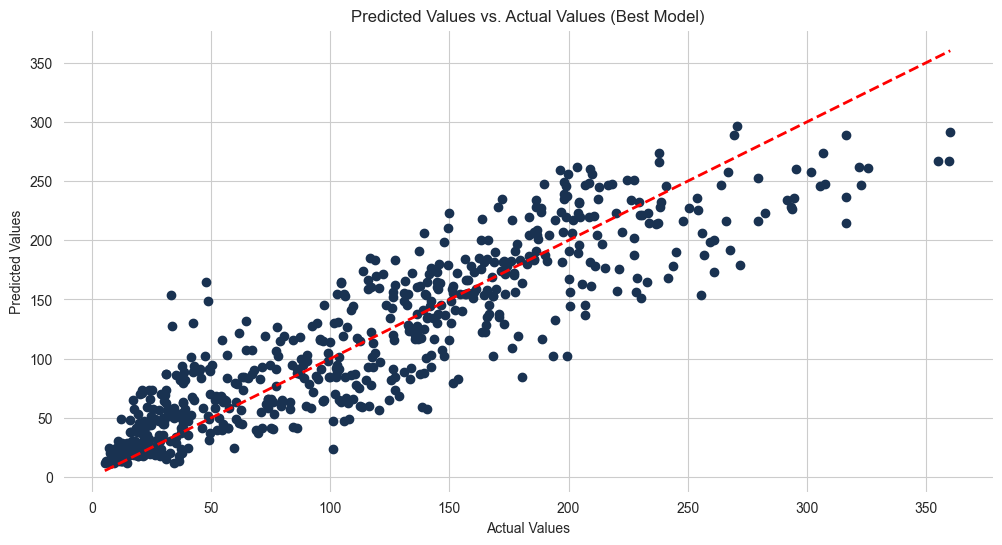

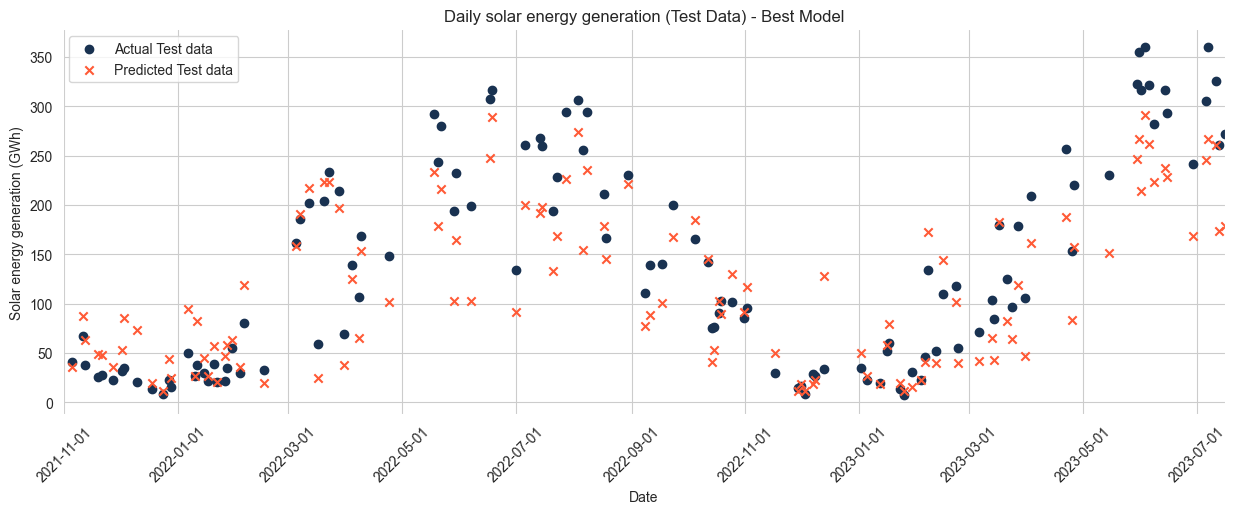

In [335]:
from sklearn.model_selection import GridSearchCV
#features=  ['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Norm_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
#features =  ['Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']#['Sunshine_hour_mean_de', 'Average_wind_speed_mpers_mean_de', 'Norm_temp_c_mean_de']#, 'Precipitation_mm_mean_de', 'Average_temp_c_mean_de', 'Max_temp_c_mean_de', 'Min_temp_c_mean_de']
features=  ['Sunshine_hour_mean_de']
target = 'Solar_gwh'


# Split data into features and target
X = data_mlvt_daily[features]
y = data_mlvt_daily[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [None, 10, 20, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Create a Random Forest model
base_model = RandomForestRegressor(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the GridSearchCV object on the data
grid_search.fit(X_train_scaled, y_train)

# Get the best model and its parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Hyperparameters:", best_params)

# Make predictions on the test set using the best model
y_pred_best = best_model.predict(X_test_scaled)

# Calculate evaluation metrics for the best model
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Best Model Evaluation:")
print("RMSE:", rmse_best)
print("MAE:", mae_best)
print("MSE:", mse_best)
print("R2 Score:", r2_best)



# Create a residual plot for the best model
residuals_best = y_test - y_pred_best
plt.scatter(y_test, residuals_best)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values (Best Model)")
plt.show()

# Create a predicted vs actual plot for the best model
plt.scatter(y_test, y_pred_best)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted Values vs. Actual Values (Best Model)")
plt.show()

# Plot test and predicted values for test data using the best model
fig, ax = plt.subplots(figsize=(15, 5))
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_test, label='Actual Test data', marker='o')
plt.scatter(data_mlvt_daily['Date'].iloc[X_test.index], y_pred_best, label='Predicted Test data', marker='x')
# Set x-axis limits to start from the 80% mark
start_idx = int(len(data_mlvt_daily) * 0.8)
end_idx = len(data_mlvt_daily)
plt.xlim(data_mlvt_daily['Date'].iloc[start_idx], data_mlvt_daily['Date'].iloc[end_idx - 1])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel('Solar energy generation (GWh)')
ax.set_xlabel('Date')
plt.xticks(rotation=45)
plt.title('Daily solar energy generation (Test Data) - Best Model')
plt.legend()
plt.show()
